# Question 1 : Belgium Netherlands Border 

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from datetime import datetime
from tqdm import tqdm
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [55]:
# Some preliminary code
def add_username(username) -> None:
    plt.text(0.95, 0.95, username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

def print_separator() -> None:
    print("\n" + "="*50 + "\n")

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

## Question 1.1 : Image Processing and Dataset Creation

Image shape: (50, 50, 3)
Binary mask shape: (50, 50)
Unique values in mask: [False  True]
Netherlands pixels (0): 1986
Belgium pixels (1): 514


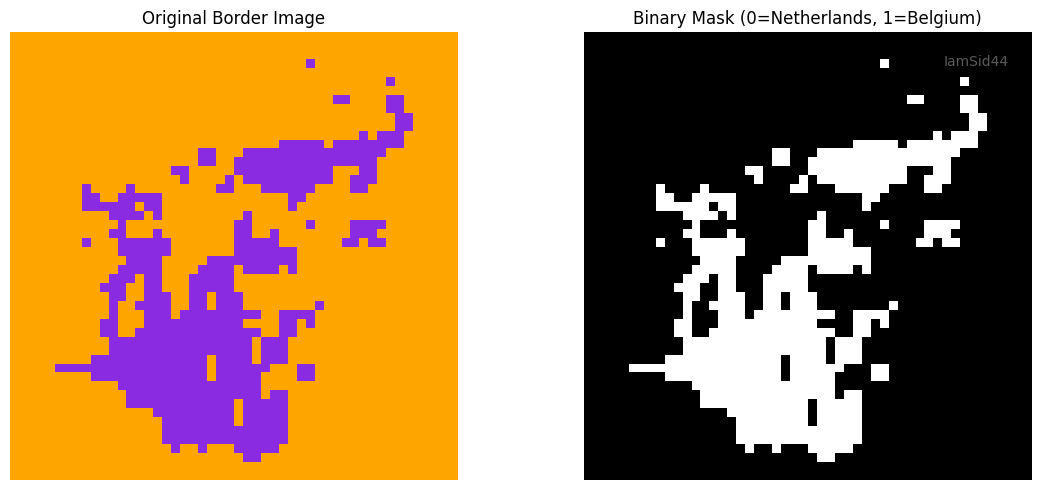


Dataset size: 2500 samples

First 5 samples:
Sample 1: coordinates=(0.3469, 0.2857), label=True
Sample 2: coordinates=(0.3469, 0.8367), label=False
Sample 3: coordinates=(0.1837, 0.1224), label=False
Sample 4: coordinates=(0.1429, 0.0816), label=False
Sample 5: coordinates=(0.4694, 0.5102), label=False


In [56]:
class BorderImageProcessor:
    """Processes the border image and converts it to a binary mask."""
    
    def __init__(self, image_path):
        """
        Initialize with the path to the border image.
        
        Args:
            image_path: Path to the pixelated border image
        """
        self.image_path = image_path
        self.image = None
        self.binary_mask = None
        self.samples = []
        
    def load_image(self):
        """Load the image from the specified path."""
        self.image = Image.open(self.image_path)
        self.image = np.array(self.image) # Converts into a numpy array
        return self.image
    
    def convert_to_binary_mask(self):
        """
        Convert the RGB image to a binary mask.
        Orange pixels (Netherlands) -> 0
        Purple pixels (Belgium) -> 1
        
        Returns:
            binary_mask: 2D numpy array with values 0 or 1
        """
        
        # Define color thresholds for orange and purple (Checked from hex codes online)
        # Orange: high R, medium G, low B
        # Purple: high R, low G, high B
        
        # Check if blue channel is higher than green
        # Purple has high blue, orange has low blue
        self.binary_mask = self.image[:, :, 2] > self.image[:, :, 1]
        
        return self.binary_mask
    
    def visualize(self):
        """Visualize the original image and binary mask side by side."""
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        axes[0].imshow(self.image)
        axes[0].set_title('Original Border Image')
        axes[0].axis('off')
        
        axes[1].imshow(self.binary_mask, cmap='gray')
        axes[1].set_title('Binary Mask (0=Netherlands, 1=Belgium)')
        axes[1].axis('off')
        
        plt.tight_layout()
        add_username("IamSid44")
        plt.show()

    def make_shuffled_dataset(self):
        """Return the dataset of normalized coordinates and labels."""
        height, width = self.binary_mask.shape

        random.seed(42)
        np.random.seed(42)

        for y in range(height):
            for x in range(width):
                # Normalize coordinates to [0, 1]
                x_norm = x / (width - 1)
                y_norm = y / (height - 1)
                # Chosen coordinate axes has origin at the bottom left corner
                y_norm = 1 - y_norm  # Flip y to have origin at bottom-left
                label = binary_mask[y, x]
                self.samples.append((x_norm, y_norm, label))
        
        random.shuffle(self.samples, ) # Shuffles the list in place

# Load and process the image
processor = BorderImageProcessor('data/Q1/border.png')
image = processor.load_image()
print(f"Image shape: {image.shape}")

binary_mask = processor.convert_to_binary_mask()
print(f"Binary mask shape: {binary_mask.shape}")
print(f"Unique values in mask: {np.unique(binary_mask)}")
print(f"Netherlands pixels (0): {np.sum(binary_mask == 0)}")
print(f"Belgium pixels (1): {np.sum(binary_mask == 1)}")

processor.visualize()

# Create dataset
processor.make_shuffled_dataset()
print(f"\nDataset size: {len(processor.samples)} samples")

print("\nFirst 5 samples:")
for i in range(5):
    x, y, label = processor.samples[i]
    print(f"Sample {i + 1}: coordinates=({x:.4f}, {y:.4f}), label={label}")

## Question 1.2 : Neural Network Implementation from Scratch

In [57]:
# ============= Activation Function Classes =============

class ReLU:
    """ReLU activation function."""
    
    def forward(self, x):
        """Forward pass: max(0, x)"""
        self.input = x # Of size (batch_size, output_width)
        return np.maximum(0, x) # Element-wise max
    
    def backward(self, grad_output):
        """Backward pass: derivative is 1 if x > 0, else 0"""
        return grad_output * (self.input >= 0) # Of same shape as input


class Tanh:
    """Tanh activation function."""
    
    def forward(self, x):
        """Forward pass: tanh(x)"""
        self.output = np.tanh(x) # Of size (batch_size, output_width)
        return self.output # Element-wise tanh
    
    def backward(self, grad_output):
        """Backward pass: derivative is 1 - tanh^2(x)"""
        return grad_output * (1 - self.output ** 2) # Of same shape as input


class Sigmoid:
    """Sigmoid activation function."""
    
    def forward(self, x):
        """Forward pass: 1 / (1 + exp(-x))"""
        self.output = 1 / (1 + np.exp(-np.clip(x, -500, 500))) # Clip to prevent overflow, Of size (batch_size, output_width)
        return self.output # Element-wise sigmoid
    
    def backward(self, grad_output):
        """Backward pass: sigmoid(x) * (1 - sigmoid(x))"""
        return grad_output * self.output * (1 - self.output) # Of same shape as input


class Identity:
    """Identity activation (no activation)."""
    
    def forward(self, x):
        """Forward pass: returns input as-is"""
        return x # Of size (batch_size, output_width)
    
    def backward(self, grad_output):
        """Backward pass: gradient passes through unchanged"""
        return grad_output # Of same shape as input

In [58]:
# ============= Linear Layer Class =============

class Linear:
    """Linear (fully connected) layer."""
    
    def __init__(self, input_width, output_width, activation='relu'):
        """
        Initialize linear layer.
        
        Args:
            input_width: Number of input features
            output_width: Number of output features
            activation: Activation function name ('relu', 'tanh', 'sigmoid', 'identity')
        """

        random.seed(42)
        np.random.seed(42)

        self.input_width = input_width
        self.output_width = output_width
        
        # Initialize weights and biases using Xavier initialization
        self.weights = np.random.randn(input_width, output_width) * np.sqrt(2.0 / input_width)
        self.biases = np.zeros((1, output_width))
        
        # Initialize cumulative gradients
        self.grad_weights = np.zeros_like(self.weights)
        self.grad_biases = np.zeros_like(self.biases)
        
        # Set activation function
        activation_map ={
            'relu': ReLU(),
            'tanh': Tanh(),
            'sigmoid': Sigmoid(),
            'identity': Identity()
        }
        # Get the 'Value' value from the key in the dictionary, pass the key in all lowercase, dedfault to ReLU
        self.activation = activation_map.get(activation.lower(), ReLU())
        
        # Store for backward pass
        self.input = None
        self.z = None
        self.output = None
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Input of shape (batch_size, input_width)
            
        Returns:
            Output after linear transformation and activation
        """
        self.input = x # Of size (batch_size, input_width)
        self.z = np.dot(x, self.weights) + self.biases # Of size (batch_size, output_width)
        self.output = self.activation.forward(self.z) # Of size (batch_size, output_width)
        return self.output # Of size (batch_size, output_width)
    
    def backward(self, grad_output):
        """
        Backward pass.
        
        Args:
            grad_output: Gradient from next layer
            
        Returns:
            Gradient to pass to previous layer
        """
        # Gradient through activation
        grad_z = self.activation.backward(grad_output) # Of size (batch_size, output_width)
        
        # Accumulate gradients for weights and biases
        self.grad_weights += np.dot(self.input.T, grad_z) # Of size (input_width, output_width)
        self.grad_biases += np.sum(grad_z, axis=0, keepdims=True) # Of size (1, output_width)
        
        # Gradient to pass to previous layer
        grad_input = np.dot(grad_z, self.weights.T) # Of size (batch_size, input_width)
        
        return grad_input # Of size (batch_size, input_width)

In [59]:
# ============= Loss Functions =============

class MSE:
    """Mean Squared Error loss function."""
    
    def forward(self, y_pred, y_true):
        """Compute MSE loss."""
        self.y_pred = y_pred # Of size (batch_size, output_width)
        self.y_true = y_true # Of size (batch_size, output_width)
        return np.sum(np.mean((y_pred - y_true) ** 2, axis=1)) # Scalar
    
    def backward(self):
        """Compute gradient of MSE loss."""
        batch_size, output_size = self.y_pred.shape
        return 2 * (self.y_pred - self.y_true) / (output_size) # Of size (batch_size, output_width)


class BCE:
    """Binary Cross Entropy loss function."""
    
    def forward(self, y_pred, y_true):
        """Compute BCE loss."""
        self.y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7) # Of size (batch_size, output_width)
        self.y_true = y_true # Of size (batch_size, output_width)
        return np.sum(-np.mean(y_true * np.log(self.y_pred) + (1 - y_true) * np.log(1 - self.y_pred), axis=1)) # Scalar
    
    def backward(self):
        """Compute gradient of BCE loss."""
        batch_size, output_size = self.y_pred.shape
        return (self.y_pred - self.y_true) / (self.y_pred * (1 - self.y_pred) * output_size) # Of size (batch_size, output_width)

In [60]:
# ============= Model Class =============

class Model:
    """Neural network model."""
    
    def __init__(self, layers, loss_type='mse'):
        """
        Initialize model.
        
        Args:
            layers: List of Linear layer objects
            loss_type: 'mse' or 'bce'
        """
        self.layers = layers

        if loss_type.lower() == 'mse':
            self.loss_fn = MSE()
        elif loss_type.lower() == 'bce':
            self.loss_fn = BCE()
        else:
            raise ValueError(f"Unknown loss type: {loss_type}")
    
    def forward(self, x):
        """
        Forward pass through all layers.
        
        Args:
            x: Input data
            
        Returns:
            Output predictions
        """
        for layer in self.layers:
            x = layer.forward(x)
        return x
    
    def backward(self, grad_output):
        """
        Backward pass through all layers.
        
        Args:
            grad_output: Gradient from loss function
        """
        for layer in reversed(self.layers):
            grad_output = layer.backward(grad_output)
    
    def train(self, x, y):
        """
        Perform one training step: forward pass, compute loss, backward pass.
        
        Args:
            x: Input data
            y: True labels
            
        Returns:
            loss: Computed loss value
        """
        # Forward pass
        y_pred = self.forward(x)
        
        # Compute loss
        loss = self.loss_fn.forward(y_pred, y)
        
        # Backward pass
        grad_loss = self.loss_fn.backward()
        self.backward(grad_loss)
        
        return loss
    
    def zero_grad(self):
        """Reset cumulative gradients in all layers to zero."""
        for layer in self.layers:
            layer.grad_weights.fill(0)
            layer.grad_biases.fill(0)
    
    def update(self, learning_rate):
        """
        Update model parameters using accumulated gradients.
        
        Args:
            learning_rate: Learning rate for gradient descent
        """
        for layer in self.layers:
            layer.weights -= learning_rate * layer.grad_weights
            layer.biases -= learning_rate * layer.grad_biases
    
    def predict(self, x):
        """
        Make predictions (forward pass without training).
        
        Args:
            x: Input data
            
        Returns:
            Predictions
        """
        return self.forward(x)
    
    def save_to(self, path, loss):
        """
        Save model parameters to file.
        
        Args:
            path: Path to save file (.npz format)
            loss: Loss value to include in filename
        """
        params = {}
        for i, layer in enumerate(self.layers):
            params[f'layer_{i}_weights'] = layer.weights
            params[f'layer_{i}_biases'] = layer.biases
        
        # Save architecture info
        architecture = {
            'num_layers': len(self.layers),
            'layer_shapes': [(layer.input_width, layer.output_width) for layer in self.layers],
            'activations': [layer.activation for layer in self.layers]
        }

        # Delete the previously saved model to save space
        for file in os.listdir(path):
            if file.startswith("model_loss_") and file.endswith(".npz"):
                os.remove(os.path.join(path, file))
    
        full_path = os.path.join(path, f"model_loss_{loss:.6f}.npz")
        np.savez(full_path, architecture=architecture, **params, loss=loss) # Unpacks params dict
        # print(f"Model saved to {full_path}")

    def load_from(self, path):
        """
        Load model parameters from file.
        
        Args:
            path: Path to saved file (.npz format)
        """
        data = np.load(path, allow_pickle=True) # To load non-numpy elements like dicts
        architecture = data['architecture'].item()
        
        # Verify architecture matches
        if len(self.layers) != architecture['num_layers']:
            raise ValueError("Model architecture doesn't match saved file!")
        
        for i, layer in enumerate(self.layers):
            expected_shape = architecture['layer_shapes'][i]
            if (layer.input_width, layer.output_width) != expected_shape:
                raise ValueError(f"Layer {i} shape mismatch!")
            
            layer.weights = data[f'layer_{i}_weights']
            layer.biases = data[f'layer_{i}_biases']
        
        print(f"Model loaded from {path}")

In [61]:
# ============= Training Procedure =============

def train_model(model, X_train, y_train, batch_size, grad_accumulation_steps, 
                learning_rate, num_epochs, patience=10, relative_loss_threshold=0.01,
                save_path=None):
    """
    Training procedure with early stopping.
    
    Args:
        model: Model instance
        X_train: Training data
        y_train: Training labels
        batch_size: Batch size
        grad_accumulation_steps: Number of steps to accumulate gradients
        learning_rate: Learning rate
        num_epochs: Maximum number of epochs
        patience: Number of epochs for early stopping
        relative_loss_threshold: Threshold for early stopping (default 0.01)
        save_path: Path to save model
    
    Returns:
        Dictionary with training history and metadata
    """

    random.seed(42)
    np.random.seed(42)

    n_samples = X_train.shape[0]
    n_batches = n_samples // batch_size
    
    epoch_loss_history = []
    batch_loss_history = []
    grad_update_loss = []
    print(f"Starting training:")
    print(f"Total samples: {n_samples}, Batch size: {batch_size}, Batches per epoch: {n_batches}")
    print(f"Gradient accumulation steps: {grad_accumulation_steps}")
    print(f"Learning rate: {learning_rate}, Max epochs: {num_epochs}")
    print_separator()
    
    best_loss = float('inf')
    epochs_without_improvement = 0
    
    # Create progress bar for epochs
    pbar = tqdm(range(num_epochs), desc="Training", unit="epoch")
    #desc = description shown at the left of the progress bar
    #unit = unit of each iteration
    
    for epoch in pbar:
        # Shuffle data
        indices = np.random.permutation(n_samples)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        epoch_loss = 0
        grad_update_loss_val = 0
        model.zero_grad()
        
        for batch_idx in range(n_batches):
            # Get batch
            start_idx = batch_idx * batch_size
            end_idx = start_idx + batch_size
            X_batch = X_shuffled[start_idx:end_idx]
            y_batch = y_shuffled[start_idx:end_idx]
            
            # Train on batch
            loss = model.train(X_batch, y_batch)
            batch_loss_history.append(loss)
            epoch_loss += loss
            grad_update_loss_val += loss
            
            # Update parameters after grad_accumulation_steps
            if (batch_idx + 1) % grad_accumulation_steps == 0:
                grad_update_loss.append(grad_update_loss_val)
                grad_update_loss_val = 0
                model.update(learning_rate)
                model.zero_grad()
        
        # Update if there are remaining gradients
        # Choose batch sizes and grad_accumulation_steps such that this condition is not needed
        # Will affect the plot if this gets executed
        if n_batches % grad_accumulation_steps != 0:
            model.update(learning_rate)
            model.zero_grad()
        
        # Average loss for epoch (not per batch)
        avg_loss = epoch_loss
        epoch_loss_history.append(avg_loss)
        
        # Update progress bar with current metrics
        pbar.set_postfix({
            'loss': f'{avg_loss:.6f}',
            'best': f'{best_loss:.6f}',
            'no_improve': epochs_without_improvement
        })
        # Display other values in the postfix
    
        if epoch == 0:
            best_loss = avg_loss
        
        # Early stopping check
        if avg_loss < best_loss:
            if best_loss - avg_loss > relative_loss_threshold * best_loss:
                epochs_without_improvement = 0
                best_loss = avg_loss
                model.save_to(save_path, best_loss)
            else:
                epochs_without_improvement += 1
        else:
            epochs_without_improvement += 1
        
        # Check early stopping condition
        if epochs_without_improvement >= patience:
            L_i = epoch_loss_history[-1]
            L_i_minus_10 = epoch_loss_history[-10]
            pbar.write(f"\nEarly stopping triggered at epoch {epoch + 1}") # Writes to console without breaking progress bar
            pbar.write(f"Loss improvement less than 1% over last {patience} epochs")
            break

    pbar.close()
    print_separator()
    print(f"Training completed! Best loss: {best_loss:.6f}, total epochs: {len(epoch_loss_history)}")
    
    # Create training history
    history = {
        'loss_history': epoch_loss_history,
        'batch_loss_history': batch_loss_history,
        'grad_update_loss': grad_update_loss,
        'hyperparameters': {
            'batch_size': batch_size,
            'grad_accumulation_steps': grad_accumulation_steps,
            'learning_rate': learning_rate,
            'num_epochs': len(epoch_loss_history),
            'patience': patience,
            'relative_loss_threshold': relative_loss_threshold
        },
        'final_loss': epoch_loss_history[-1],
        'best_loss': best_loss
    }
    
    return history

In [62]:
def plot_training_history(history):
    """
    Plot training loss vs epochs.
    
    Args:
        history: Dictionary from train_model
    """
    epoch_loss_history = history['loss_history']
    batch_loss_history = history['batch_loss_history']
    
    epochs = len(epoch_loss_history)
    epochs_axis = np.arange(1, epochs + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_axis, epoch_loss_history, linewidth=2, label='Epoch Loss')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss per epoch', fontsize=12)
    plt.title(f'Training Loss vs Epochs', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    add_username("siddarth.g")
    plt.show()

    # Loss vs samples seen
    x_ticks = np.arange(1, len(history['grad_update_loss']) + 1) * history['hyperparameters']['batch_size'] * history['hyperparameters']['grad_accumulation_steps']

    plt.figure(figsize=(10, 6))
    plt.plot(x_ticks, history['grad_update_loss'], linewidth=2, label='Batch Loss')
    plt.xlabel('Total Samples Seen', fontsize=12)
    plt.ylabel('Loss per Grad Update', fontsize=12)
    plt.title(f'Training Loss vs Total Samples Seen', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    add_username("siddarth.g")
    plt.show()

## Question 1.3 : Sanity Check

### 1.3.1 The XOR Problem

XOR Dataset size: 4 samples
XOR Dataset Type: int64, Labels Type: int64
10 samples:
  Input: [0 1], Predicted: [1]
  Input: [1 1], Predicted: [0]
  Input: [0 0], Predicted: [0]
  Input: [1 0], Predicted: [1]
Starting training:
Total samples: 4, Batch size: 4, Batches per epoch: 1
Gradient accumulation steps: 1
Learning rate: 0.1, Max epochs: 10000




Training:  12%|█▏        | 1226/10000 [00:03<00:24, 353.46epoch/s, loss=0.000585, best=0.000591, no_improve=9]



Early stopping triggered at epoch 1227
Loss improvement less than 1% over last 10 epochs


Training completed! Best loss: 0.000591, total epochs: 1227


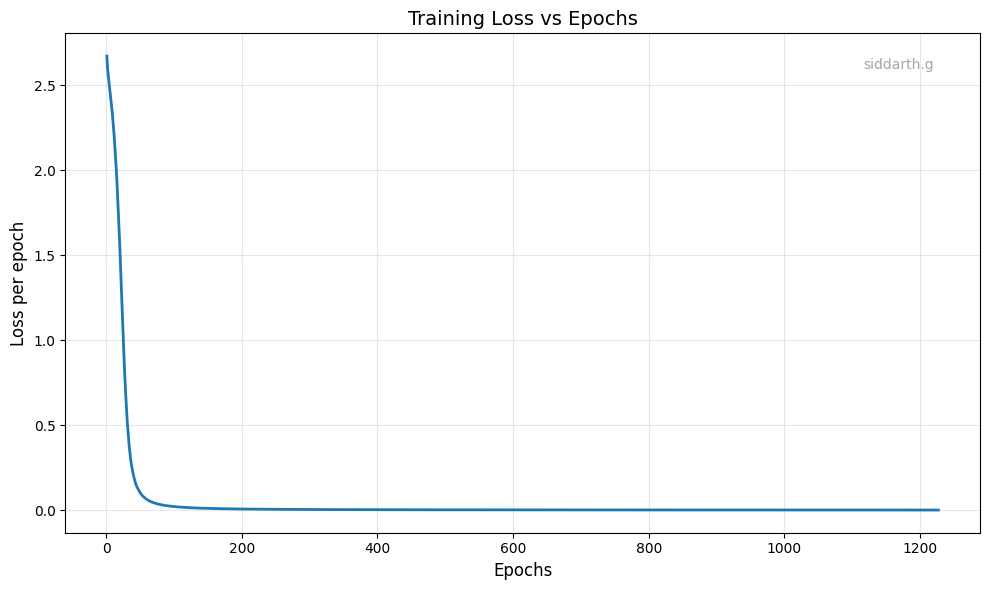

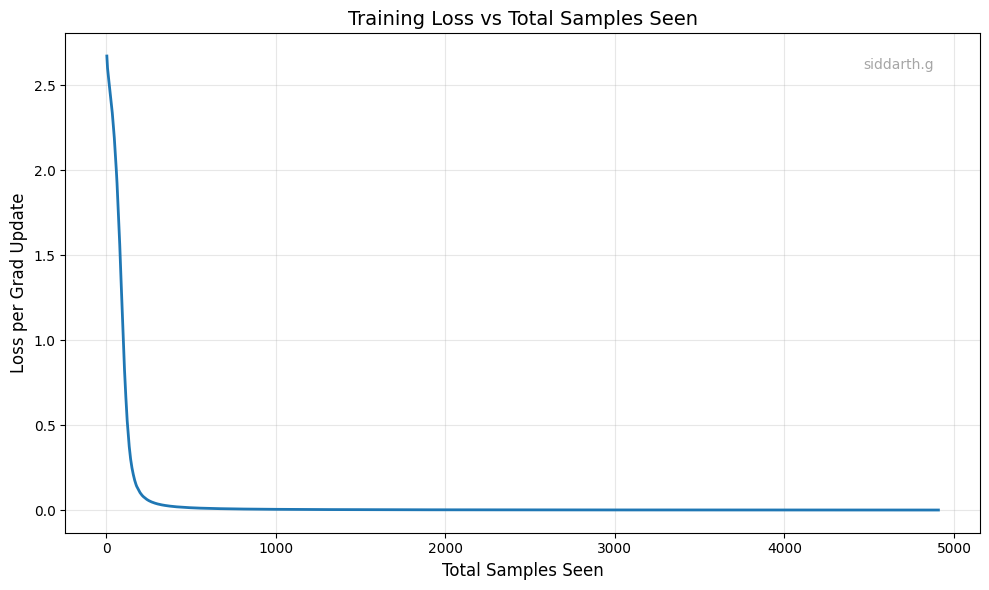

XOR Test Accuracy: 1.0000
Predicted 1s: 2, Predicted 0s: 2
Input: [0 0], Predicted Probability: 0.0001, Predicted Label: 0
Input: [0 1], Predicted Probability: 0.9998, Predicted Label: 1
Input: [1 0], Predicted Probability: 0.9999, Predicted Label: 1
Input: [1 1], Predicted Probability: 0.0002, Predicted Label: 0


In [63]:
# XOR Dataset

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

duplicate_train = 1
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])
X_train = np.repeat(X, duplicate_train, axis=0)
y_train = np.repeat(y, duplicate_train, axis=0)
indices = np.random.permutation(X_train.shape[0])
X_shuffled = X_train[indices]
y_shuffled = y_train[indices]

duplicate_test = 1
X_test = np.repeat(X, duplicate_test, axis=0)
y_test = np.repeat(y, duplicate_test, axis=0)

print(f"XOR Dataset size: {X_train.shape[0]} samples")
print(f"XOR Dataset Type: {X_train.dtype}, Labels Type: {y_train.dtype}")
print("10 samples:")
for i in range(4):
    print(f"  Input: {X_shuffled[i]}, Predicted: {y_shuffled[i]}")

# Model number 1
layers = [
    Linear(2, 4, activation='relu'),
    Linear(4, 8, activation='tanh'),
    Linear(8, 8, activation='sigmoid'),
    Linear(8, 4, activation='identity'),
    Linear(4, 1, activation='sigmoid')
]

model = Model(layers, loss_type='bce')
path = 'models/run_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
os.makedirs(path, exist_ok=True)
history = train_model(
    model=model,
    X_train=X_shuffled,
    y_train=y_shuffled,
    batch_size=4,
    grad_accumulation_steps=1,
    relative_loss_threshold=0.01,
    learning_rate=0.1,
    num_epochs=10000,
    patience=10,
    save_path=path
)

plot_training_history(history)
y_pred = model.predict(X_test)
y_labels = (y_pred >= 0.5).astype(int)
accuracy = np.mean(y_labels == y_test)
print(f"XOR Test Accuracy: {accuracy:.4f}")

# Predict number of 1s and 0s
num_ones = np.sum(y_labels)
num_zeros = y_labels.shape[0] - num_ones
print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")

# Print the y_pred values and the predictions
for i in range(len(y_pred)):
    print(f"Input: {X_test[i]}, Predicted Probability: {y_pred[i][0]:.4f}, Predicted Label: {y_labels[i][0]}")

# Find accuracy on the train set itself
# y_pred = model.predict(X_shuffled)
# y_labels = (y_pred >= 0.5).astype(int)
# accuracy = np.mean(y_labels == y_shuffled)
# num_ones = np.sum(y_labels)
# num_zeros = y_labels.shape[0] - num_ones
# print(f"Train set accuracy: {accuracy:.4f}, Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")

Starting training:
Total samples: 4, Batch size: 4, Batches per epoch: 1
Gradient accumulation steps: 1
Learning rate: 0.1, Max epochs: 10000




Training:  11%|█         | 1095/10000 [00:03<00:26, 341.98epoch/s, loss=0.003354, best=0.003387, no_improve=9]



Early stopping triggered at epoch 1096
Loss improvement less than 1% over last 10 epochs


Training completed! Best loss: 0.003387, total epochs: 1096


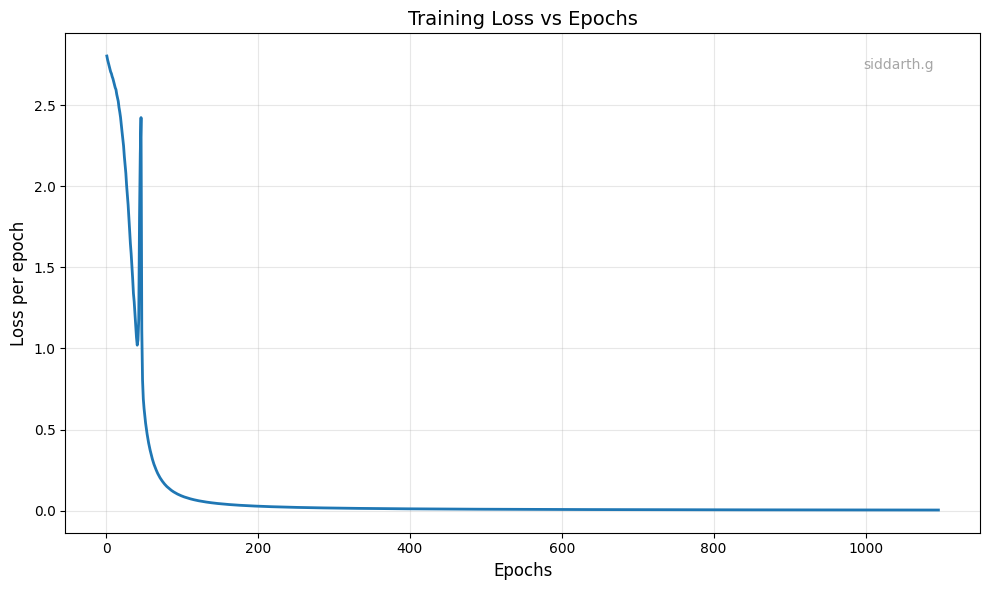

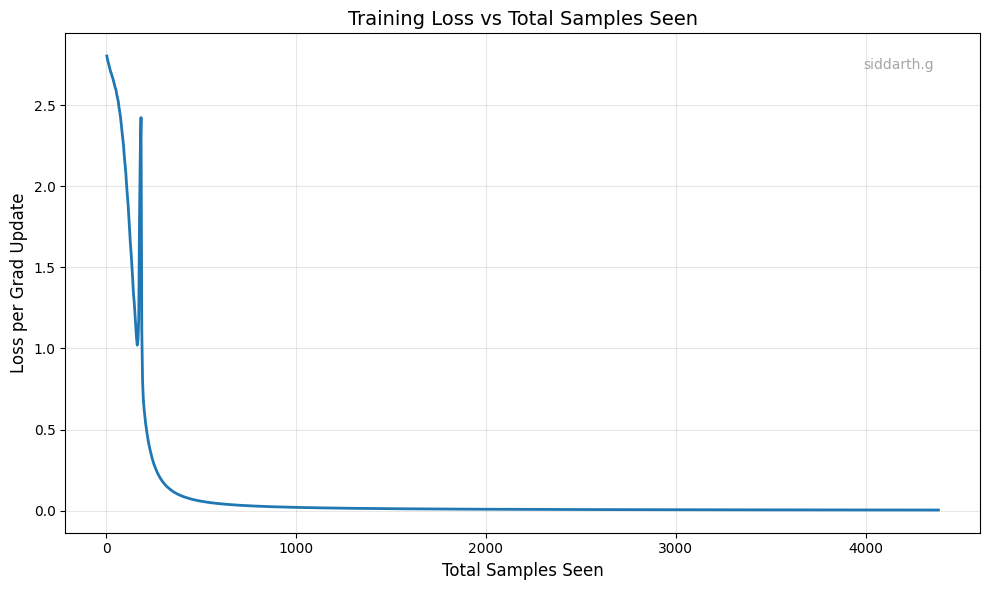

XOR Test Accuracy: 1.0000
Predicted 1s: 2, Predicted 0s: 2
Input: [0 0], Predicted Probability: 0.0006, Predicted Label: 0
Input: [0 1], Predicted Probability: 0.9991, Predicted Label: 1
Input: [1 0], Predicted Probability: 0.9992, Predicted Label: 1
Input: [1 1], Predicted Probability: 0.0011, Predicted Label: 0


In [64]:
# Model number 2
layers = [
    Linear(2, 4, activation='relu'),
    Linear(4, 8, activation='identity'),
    Linear(8, 8, activation='sigmoid'),
    Linear(8, 4, activation='tanh'),
    Linear(4, 1, activation='sigmoid')
]

model = Model(layers, loss_type='bce')
path = 'models/run_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
os.makedirs(path, exist_ok=True)
history = train_model(
    model=model,
    X_train=X_shuffled,
    y_train=y_shuffled,
    batch_size=4,
    grad_accumulation_steps=1,
    relative_loss_threshold=0.01,
    learning_rate=0.1,
    num_epochs=10000,
    patience=10,
    save_path=path
)

plot_training_history(history)
y_pred = model.predict(X_test)
y_labels = (y_pred >= 0.5).astype(int)
accuracy = np.mean(y_labels == y_test)
print(f"XOR Test Accuracy: {accuracy:.4f}")

# Predict number of 1s and 0s
num_ones = np.sum(y_labels)
num_zeros = y_labels.shape[0] - num_ones
print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")

# Print the y_pred values and the predictions
for i in range(len(y_pred)):
    print(f"Input: {X_test[i]}, Predicted Probability: {y_pred[i][0]:.4f}, Predicted Label: {y_labels[i][0]}")

# Find accuracy on the train set itself
# y_pred = model.predict(X_shuffled)
# y_labels = (y_pred >= 0.5).astype(int)
# accuracy = np.mean(y_labels == y_shuffled)
# num_ones = np.sum(y_labels)
# num_zeros = y_labels.shape[0] - num_ones
# print(f"Train set accuracy: {accuracy:.4f}, Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")

Starting training:
Total samples: 4, Batch size: 4, Batches per epoch: 1
Gradient accumulation steps: 1
Learning rate: 0.1, Max epochs: 10000




Training:  12%|█▏        | 1154/10000 [00:03<00:29, 301.27epoch/s, loss=0.012182, best=0.012305, no_improve=9]



Early stopping triggered at epoch 1155
Loss improvement less than 1% over last 10 epochs


Training completed! Best loss: 0.012305, total epochs: 1155


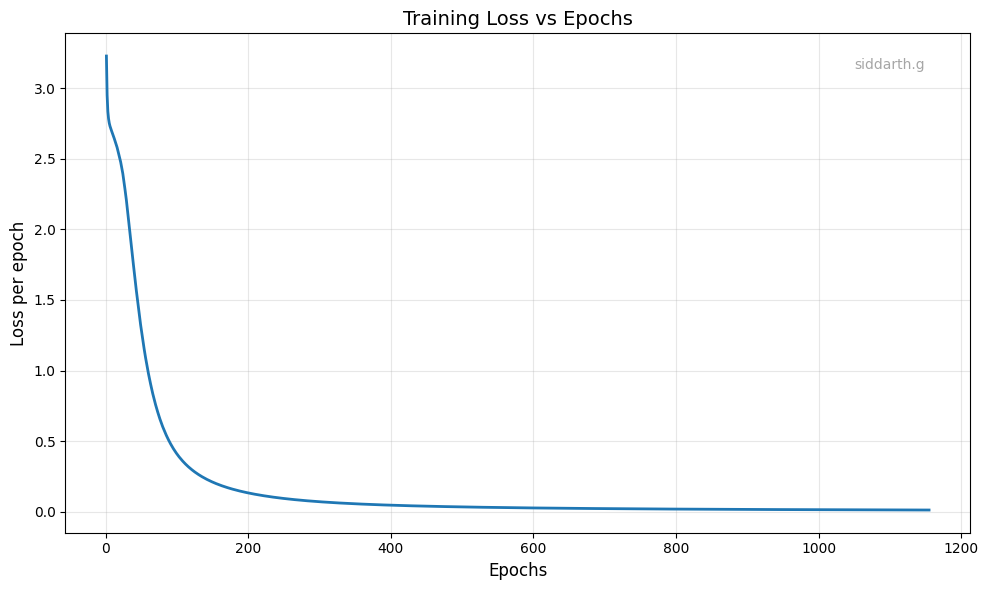

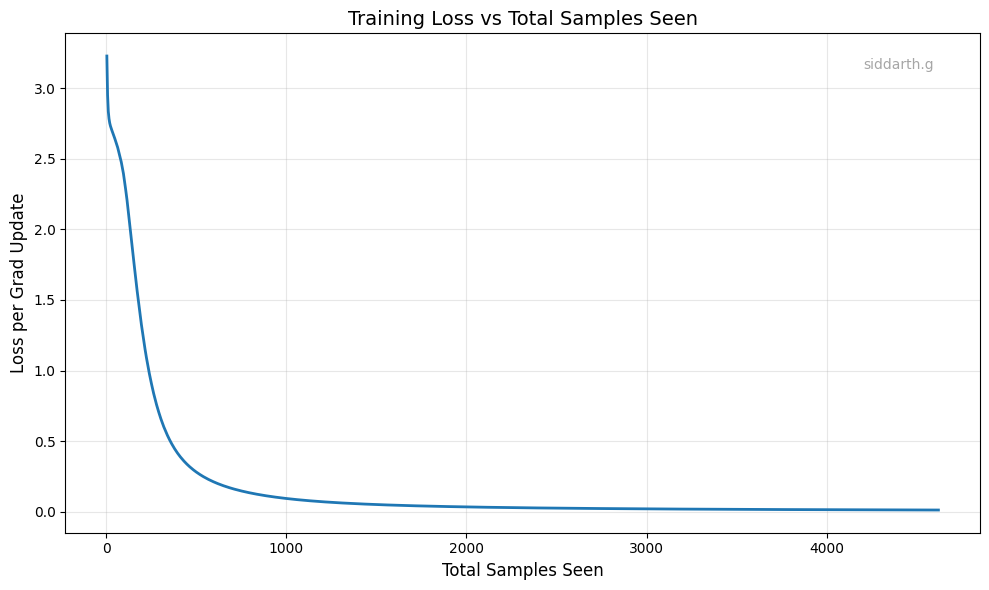

XOR Test Accuracy: 1.0000
Predicted 1s: 2, Predicted 0s: 2
Input: [0 0], Predicted Probability: 0.0032, Predicted Label: 0
Input: [0 1], Predicted Probability: 0.9975, Predicted Label: 1
Input: [1 0], Predicted Probability: 0.9979, Predicted Label: 1
Input: [1 1], Predicted Probability: 0.0043, Predicted Label: 0


In [65]:
# Model number 3
layers = [
    Linear(2, 4, activation='relu'),
    Linear(4, 8, activation='identity'),
    Linear(8, 8, activation='tanh'),
    Linear(8, 4, activation='sigmoid'),
    Linear(4, 1, activation='sigmoid')
]

model = Model(layers, loss_type='bce')
path = 'models/run_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
os.makedirs(path, exist_ok=True)
history = train_model(
    model=model,
    X_train=X_shuffled,
    y_train=y_shuffled,
    batch_size=4,
    grad_accumulation_steps=1,
    relative_loss_threshold=0.01,
    learning_rate=0.1,
    num_epochs=10000,
    patience=10,
    save_path=path
)

plot_training_history(history)
y_pred = model.predict(X_test)
y_labels = (y_pred >= 0.5).astype(int)
accuracy = np.mean(y_labels == y_test)
print(f"XOR Test Accuracy: {accuracy:.4f}")

# Predict number of 1s and 0s
num_ones = np.sum(y_labels)
num_zeros = y_labels.shape[0] - num_ones
print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")

# Print the y_pred values and the predictions
for i in range(len(y_pred)):
    print(f"Input: {X_test[i]}, Predicted Probability: {y_pred[i][0]:.4f}, Predicted Label: {y_labels[i][0]}")

# Find accuracy on the train set itself
# y_pred = model.predict(X_shuffled)
# y_labels = (y_pred >= 0.5).astype(int)
# accuracy = np.mean(y_labels == y_shuffled)
# num_ones = np.sum(y_labels)
# num_zeros = y_labels.shape[0] - num_ones
# print(f"Train set accuracy: {accuracy:.4f}, Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")

Starting training:
Total samples: 4, Batch size: 4, Batches per epoch: 1
Gradient accumulation steps: 1
Learning rate: 0.1, Max epochs: 10000




Training:  10%|█         | 1009/10000 [00:02<00:23, 383.67epoch/s, loss=0.012126, best=0.012246, no_improve=9]



Early stopping triggered at epoch 1010
Loss improvement less than 1% over last 10 epochs


Training completed! Best loss: 0.012246, total epochs: 1010


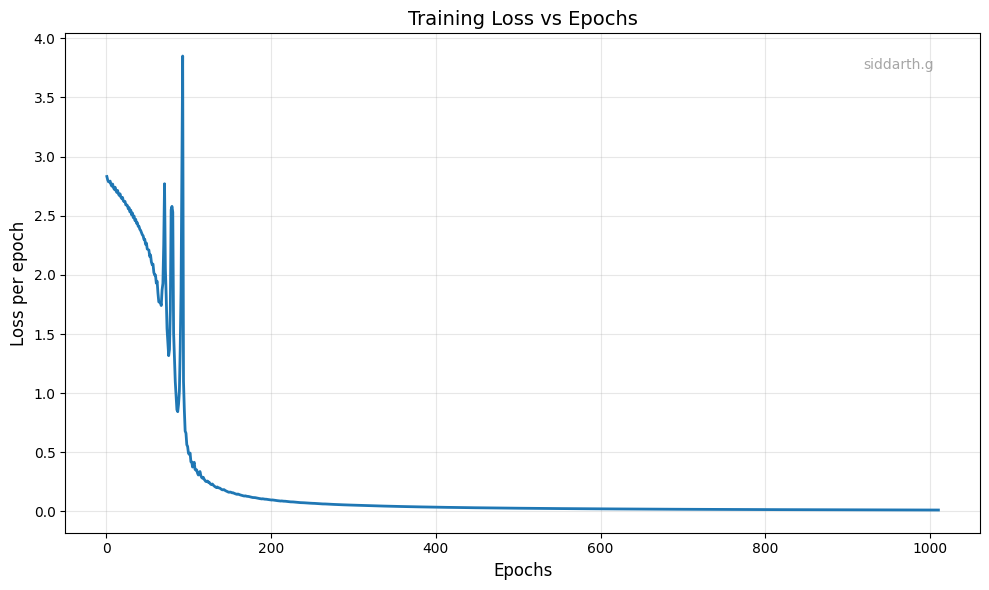

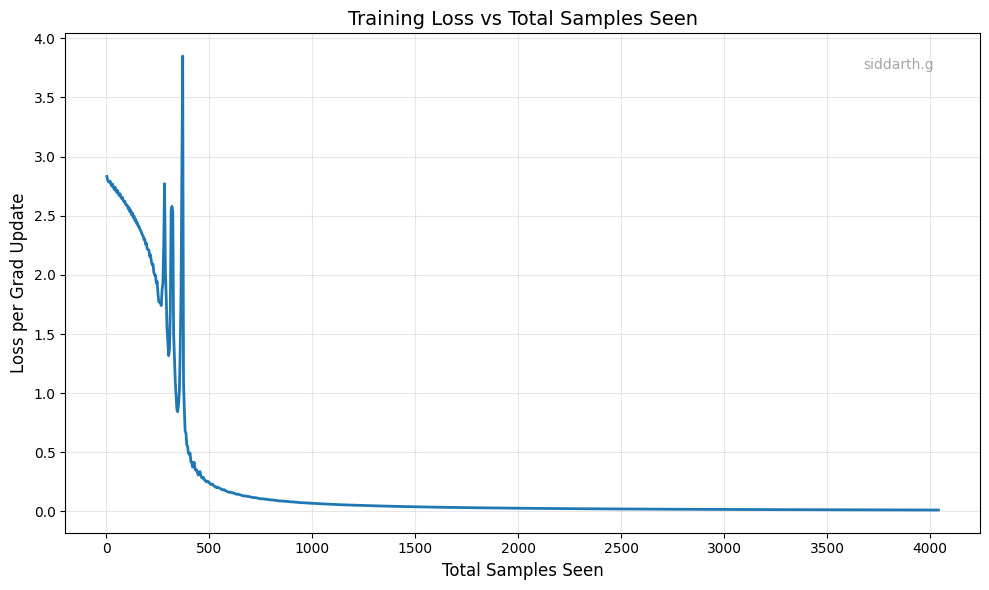

XOR Test Accuracy: 1.0000
Predicted 1s: 2, Predicted 0s: 2
Input: [0 0], Predicted Probability: 0.0058, Predicted Label: 0
Input: [0 1], Predicted Probability: 0.9997, Predicted Label: 1
Input: [1 0], Predicted Probability: 0.9997, Predicted Label: 1
Input: [1 1], Predicted Probability: 0.0058, Predicted Label: 0


In [66]:
# Model number 4
layers = [
    Linear(2, 4, activation='tanh'),
    Linear(4, 8, activation='identity'),
    Linear(8, 8, activation='sigmoid'),
    Linear(8, 4, activation='relu'),
    Linear(4, 1, activation='sigmoid')
]

model = Model(layers, loss_type='bce')
path = 'models/run_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
os.makedirs(path, exist_ok=True)
history = train_model(
    model=model,
    X_train=X_shuffled,
    y_train=y_shuffled,
    batch_size=4,
    grad_accumulation_steps=1,
    relative_loss_threshold=0.01,
    learning_rate=0.1,
    num_epochs=10000,
    patience=10,
    save_path=path
)

plot_training_history(history)
y_pred = model.predict(X_test)
y_labels = (y_pred >= 0.5).astype(int)
accuracy = np.mean(y_labels == y_test)
print(f"XOR Test Accuracy: {accuracy:.4f}")

# Predict number of 1s and 0s
num_ones = np.sum(y_labels)
num_zeros = y_labels.shape[0] - num_ones
print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")

# Print the y_pred values and the predictions
for i in range(len(y_pred)):
    print(f"Input: {X_test[i]}, Predicted Probability: {y_pred[i][0]:.4f}, Predicted Label: {y_labels[i][0]}")

# Find accuracy on the train set itself
# y_pred = model.predict(X_shuffled)
# y_labels = (y_pred >= 0.5).astype(int)
# accuracy = np.mean(y_labels == y_shuffled)
# num_ones = np.sum(y_labels)
# num_zeros = y_labels.shape[0] - num_ones
# print(f"Train set accuracy: {accuracy:.4f}, Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")

### 1.3.2 Gradient Approximation

In [67]:
def compute_numerical_gradient(model, X, y, param_layer_idx, param_type, 
                               param_idx, epsilon=1e-5):
    """
    Compute numerical gradient using finite differences.
    
    Args:
        model: Model instance
        X: Input data
        y: True labels
        param_layer_idx: Index of layer
        param_type: 'weights' or 'biases'
        param_idx: Index into parameter array (tuple for weights)
        epsilon: Small perturbation value
        
    Returns:
        Numerical gradient approximation
    """
    layer = model.layers[param_layer_idx]
    
    # Get parameter reference
    if param_type == 'weights':
        params = layer.weights
    else:
        params = layer.biases
    
    # Store original value
    original_value = params[param_idx]
    print(f"Original param value: {original_value}")
    
    # Compute loss with θ + ε
    params[param_idx] = original_value + epsilon
    print(f"Param value increased by epsilon: {params[param_idx]}")
    # model.zero_grad()
    y_pred_plus = model.forward(X)
    loss_plus = model.loss_fn.forward(y_pred_plus, y)
    
    # Compute loss with θ - ε
    params[param_idx] = original_value - epsilon
    print(f"Param value decreased by epsilon: {params[param_idx]}")
    # model.zero_grad()
    y_pred_minus = model.forward(X)
    loss_minus = model.loss_fn.forward(y_pred_minus, y)
    
    # Put back the orgnl value, run the model again to restore internal states
    params[param_idx] = original_value
    y_pred_orgnl = model.forward(X)
    loss_orgnl = model.loss_fn.forward(y_pred_orgnl, y)
    
    # Numerical gradient
    numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)
    
    return numerical_grad


def verify_gradients(model, X, y, num_params_to_check=10, epsilon=1e-5):
    """
    Verify that backpropagation gradients match numerical gradients.
    
    Args:
        model: Model instance
        X: Input data
        y: True labels
        num_params_to_check: Number of random parameters to check
        epsilon: Epsilon for numerical gradient
        
    Returns:
        Dictionary with verification results
    """
    print_separator()
    print("Gradient check using numerical approximation")
    random.seed(42)
    np.random.seed(42)
    
    # Forward pass and backward pass to compute analytical gradients
    model.zero_grad()
    y_pred = model.forward(X)
    loss = model.loss_fn.forward(y_pred, y)
    grad_loss = model.loss_fn.backward()
    model.backward(grad_loss)
    
    results = []
    max_error = 0
    cum_error = 0
    
    print(f"Checking {num_params_to_check} random parameters...")
    print(f"Using epsilon = {epsilon}")
    
    # Sample random parameters to check
    params_to_check = []
    for layer_idx, layer in enumerate(model.layers):
        # Weight parameters
        for _ in range(min(3, layer.weights.size)):
            # Pick idx1 and idx2 from the shape of weights
            # Pack them as a tuple and store in idx
            idx1 = np.random.randint(0, layer.weights.shape[0])
            idx2 = np.random.randint(0, layer.weights.shape[1])
            idx = (idx1, idx2)
            # print(layer.weights.shape)
            params_to_check.append((layer_idx, 'weights', idx))
            # print(idx)

        # Bias parameters
        for _ in range(min(2, layer.biases.size)):
            idx1 = np.random.randint(0, layer.biases.shape[0])
            idx2 = np.random.randint(0, layer.biases.shape[1])
            idx = (idx1, idx2)
            # print(layer.biases.shape)
            params_to_check.append((layer_idx, 'biases', idx))
            # print(idx)
    
    # Randomly sample if we have too many
    if len(params_to_check) > num_params_to_check:
        selected_indices = np.random.choice(len(params_to_check), num_params_to_check, replace=False)
        params_to_check = [params_to_check[i] for i in selected_indices]

    avg_error = 0
    avg_rel_error = 0
    
    # Check
    for i, (layer_idx, param_type, param_idx) in enumerate(params_to_check):
        # print(param_idx)
        layer = model.layers[layer_idx]
        
        # Get analytical gradient
        if param_type == 'weights':
            analytical_grad = layer.grad_weights[param_idx]
        else:
            analytical_grad = layer.grad_biases[param_idx]

        # If the weight/bias value is 0, skip it
        if param_type == 'weights' and layer.weights[param_idx] == 0:
            print(f"Param {i + 1}: Layer {layer_idx}, {param_type}{param_idx} - Skipping zero weight")
            continue
        if param_type == 'biases' and layer.biases[param_idx] == 0:
            print(f"Param {i + 1}: Layer {layer_idx}, {param_type}{param_idx} - Skipping zero bias")
            continue

        # Compute numerical gradient
        numerical_grad = compute_numerical_gradient(model, X, y, layer_idx, param_type, param_idx, epsilon)
        
        # model.zero_grad()
        
        # Compute errors
        abs_error = abs(analytical_grad - numerical_grad)
        rel_error = abs_error / (abs(analytical_grad) + epsilon)
        
        cum_error += abs_error
        max_error = max(max_error, abs_error)
        curr_error = abs_error
        avg_error += abs_error
        avg_rel_error += rel_error

        results.append({
            'layer': layer_idx,
            'param_type': param_type,
            'param_idx': param_idx,
            'analytical': analytical_grad,
            'numerical': numerical_grad,
            'cumulative_error': cum_error,
            'max_error': max_error,
            'current_error': curr_error,
            'relative_error': rel_error
        })

        print(f"Param {i + 1}: Layer {layer_idx}, {param_type}{param_idx}, Analytical: {analytical_grad:.6e}, Numerical: {numerical_grad:.6e}, Abs Error: {abs_error:.6e}")

        if curr_error > epsilon:
            print(f"Param {i + 1}: Layer {layer_idx}, {param_type}{param_idx} - ERROR too high!")
            print(f"  Analytical: {analytical_grad:.6e}, Numerical: {numerical_grad:.6e}")
            print(f"  Absolute Error: {curr_error:.6e}, Relative Error: {rel_error:.6e}")
    
    print(f"Max error: {max_error:.6e}")
    print(f"Cumulative error: {cum_error:.6e}")

    avg_error /= len(results)
    avg_rel_error /= len(results)

    print(f"Average absolute error: {avg_error:.6e}")
    print(f"Average relative error: {avg_rel_error:.6e}")

    print_separator()
    
    return results


def plot_gradient_comparison(results):
    """Plot comparison of analytical vs numerical gradients."""
    analytical = [r['analytical'] for r in results]
    numerical = [r['numerical'] for r in results]
    
    plt.figure(figsize=(10, 6))
    
    # 2 plots, the first plots the gradient value on the y-axis and the parameter index on the x-axis. Analytical gradients are shown in blue, numerical gradients in orange. The second plot plots the curr error value on the y-axis and the parameter index on the x-axis.
    plt.subplot(1, 2, 1)
    plt.plot(analytical, 'o-', label='Analytical Gradients', color='blue')
    plt.plot(numerical, 'o-', label='Numerical Gradients', color='orange')
    plt.xlabel('Parameter Index', fontsize=12)
    plt.ylabel('Gradient Value', fontsize=12)
    plt.title('Gradients', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot([r['current_error'] for r in results], 'o-', label='Current Error', color='green')
    plt.xlabel('Parameter Index', fontsize=12)
    plt.ylabel('Absolute Error', fontsize=12)
    plt.title('Current Error', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    add_username("siddarth.g")
    plt.show()

XOR Dataset size: 4 samples
XOR Dataset Type: int64, Labels Type: int64


Gradient check using numerical approximation
Checking 100 random parameters...
Using epsilon = 1e-06
Original param value: 1.5230298564080254
Param value increased by epsilon: 1.5230308564080253
Param value decreased by epsilon: 1.5230288564080254
Param 1: Layer 0, weights(0, 3), Analytical: 1.499321e-02, Numerical: 1.499321e-02, Abs Error: 3.853768e-12
Original param value: 0.6476885381006925
Param value increased by epsilon: 0.6476895381006925
Param value decreased by epsilon: 0.6476875381006925
Param 2: Layer 0, weights(0, 2), Analytical: -4.847432e-02, Numerical: -4.847432e-02, Abs Error: 2.319168e-10
Original param value: 1.5230298564080254
Param value increased by epsilon: 1.5230308564080253
Param value decreased by epsilon: 1.5230288564080254
Param 3: Layer 0, weights(0, 3), Analytical: 1.499321e-02, Numerical: 1.499321e-02, Abs Error: 3.853768e-12
Param 4: Layer 0, biases(0, 0) - Skipping zero bias
Param 

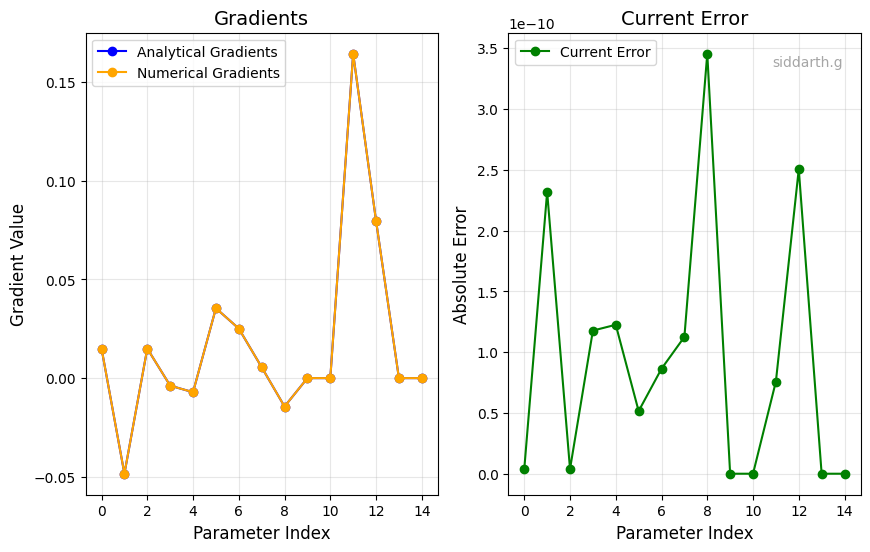

In [68]:
# XOR Dataset

print(f"XOR Dataset size: {X_train.shape[0]} samples")
print(f"XOR Dataset Type: {X_train.dtype}, Labels Type: {y_train.dtype}")

layers = [
    Linear(2, 4, activation='tanh'),
    Linear(4, 8, activation='identity'),
    Linear(8, 8, activation='sigmoid'),
    Linear(8, 4, activation='relu'),
    Linear(4, 1, activation='sigmoid')
]

model = Model(layers, loss_type='bce')

# Perform gradient check
results = verify_gradients(model, X_shuffled, y_shuffled, num_params_to_check=100, epsilon=1e-6)

plot_gradient_comparison(results)

## Question 1.4 : Map Prediction and Analysis

In [69]:
def class_visualizer(samples, y_pred, y_true, accuracy, save_path=None):
    """
    Function that takes in samples and creates visualization with 4 subplots.
    
    Args:
        samples: Array of tuples with (x, y, label) - coordinates normalized [0,1]
        y_pred: Model predictions (probabilities)
        y_true: True labels
        accuracy: Achieved accuracy
        save_path: Path to save the figure (optional)
    """

    height, width = binary_mask.shape
    # print(f"Height: {height}, width: {width}")
    
    # Initialize images
    gt_image = np.zeros((height, width))
    pred_image = np.zeros((height, width))
    error_image = np.zeros((height, width))
    
    # Convert predictions to binary labels
    y_pred_binary = (y_pred >= 0.5).astype(int)

    # print(f"Size of samples: {len(samples)}")
    # check = np.zeros((height, width))
    
    # Fill images from samples
    for i, (x_norm, y_norm, true_label) in enumerate(samples):
        # Convert normalized coordinates back to pixel coordinates
        # Was facing issues with precision, hence had to round and then convert to integers
        x_pixel = np.round(x_norm * (width - 1)).astype(int)
        y_pixel = np.round((1 - y_norm) * (height - 1)).astype(int)  # Flip y back to image coordinates

        # print(f"X pixel: {x_pixel}, Y pixexl: {y_pixel}")
        
        # Fill images
        gt_image[y_pixel, x_pixel] = true_label
        pred_image[y_pixel, x_pixel] = y_pred_binary[i]
        error_image[y_pixel, x_pixel] = abs(true_label - y_pred_binary[i])
        # check[y_pixel, x_pixel] = 1

    # Print the check matrix
    # for i in range(height):
    #     for j in range(width):
    #         if check[i, j] == 0:
    #             print(f"Check matrix - Row: {i}, Col: {j}, Value: {check[i, j]}")

    # Print number of 0s in check matrix
    # print(f"Number of missed elements: {sum(sum(check == 0))}")

    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred_binary)
    
    # Create 2x2 subplot figure
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Subplot 1: Ground Truth
    axes[0, 0].imshow(gt_image, cmap='gray')
    axes[0, 0].set_title('Ground Truth', fontsize=12)
    axes[0, 0].axis('off')
    
    # Subplot 2: Predictions
    axes[0, 1].imshow(pred_image, cmap='gray')
    axes[0, 1].set_title('Predictions', fontsize=12)
    axes[0, 1].axis('off')
    
    # Subplot 3: Error Map
    axes[1, 0].imshow(error_image, cmap='Reds')
    axes[1, 0].set_title('Error Map (Red = Wrong)', fontsize=12)
    axes[1, 0].axis('off')
    
    # Subplot 4: Confusion Matrix with annotations
    im = axes[1, 1].imshow(cm, cmap='Blues', interpolation='nearest')
    axes[1, 1].set_title('Confusion Matrix', fontsize=12)
    
    # Add confusion matrix labels
    classes = ['Netherlands (0)', 'Belgium (1)']
    tick_marks = np.arange(len(classes))
    axes[1, 1].set_xticks(tick_marks)
    axes[1, 1].set_yticks(tick_marks)
    axes[1, 1].set_xticklabels(classes)
    axes[1, 1].set_yticklabels(classes)
    axes[1, 1].set_ylabel('True Label')
    axes[1, 1].set_xlabel('Predicted Label')

    # Add text annotations to confusion matrix
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[1, 1].text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black")
    
    # Add colorbar for confusion matrix
    plt.colorbar(im, ax=axes[1, 1], shrink=0.8)
    
    # Overall title with accuracy
    fig.suptitle(f'Classification Accuracy: {accuracy:.2%}', 
                 fontsize=16, y=0.95)
    
    plt.tight_layout()
    add_username("siddarth.g")
    
    # Save figure if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Visualization saved to {save_path}")
    
    plt.show()

In [76]:
# processor.samples is a list of tuples (x_norm, y_norm, label)
# Convert to numpy arrays
# y = np.hstack([1 - y, y]) # Convert to one-hot encoding, Shape (num_samples, 2)
y = np.array([[sample[2]] for sample in processor.samples]) # Shape (num_samples, 1)
X = np.array([[sample[0], sample[1]] for sample in processor.samples]) # Shape (num_samples, 2)

# Model architecture 1
layers = [
    Linear(2, 64, activation='tanh'),
    Linear(64, 32, activation='tanh'),
    Linear(32, 32, activation='tanh'),
    Linear(32, 16, activation='tanh'),
    Linear(16, 1, activation='sigmoid')
]

model = Model(layers, loss_type='bce')
path = 'models/run_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
os.makedirs(path, exist_ok=True)
history = train_model(
    model=model,
    X_train=X,
    y_train=y,
    batch_size=125,
    grad_accumulation_steps=1,
    relative_loss_threshold=0.01,
    learning_rate=0.01,
    num_epochs=10000,
    patience=500,
    save_path=path
)

Starting training:
Total samples: 2500, Batch size: 125, Batches per epoch: 20
Gradient accumulation steps: 1
Learning rate: 0.01, Max epochs: 10000




Training:  25%|██▍       | 2484/10000 [00:34<01:44, 71.69epoch/s, loss=323.362806, best=175.453529, no_improve=499]


Early stopping triggered at epoch 2485
Loss improvement less than 1% over last 500 epochs


Training completed! Best loss: 175.453529, total epochs: 2485


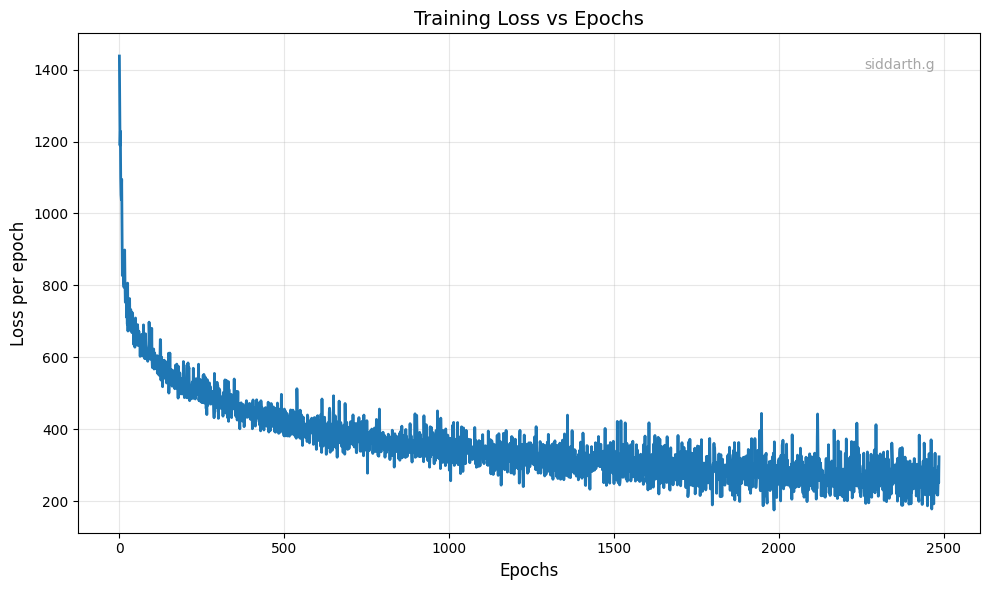

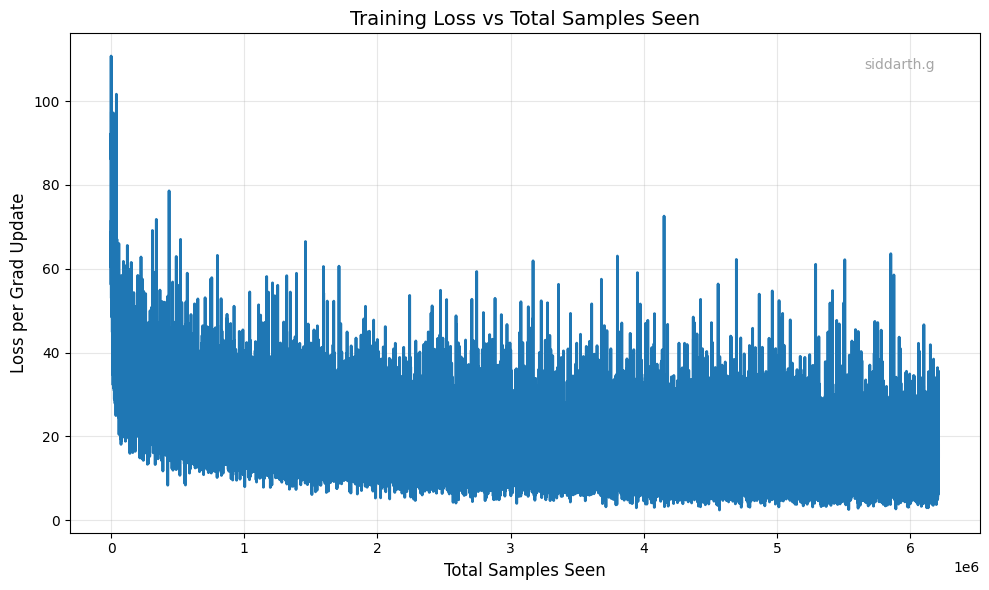

Accuracy: 0.9568
Predicted 1s: 500, Predicted 0s: 2000
Actual number of 1s: [514], 0s: [1986]
Input: [0.34693878 0.28571429], NN Output: 1.0000, Predicted: 1, True: [1]
Input: [0.65306122 0.24489796], NN Output: 0.3285, Predicted: 0, True: [1]
Input: [0.40816327 0.91836735], NN Output: 0.0000, Predicted: 0, True: [0]
Input: [0.         0.26530612], NN Output: 0.0007, Predicted: 0, True: [0]
Input: [0.57142857 0.16326531], NN Output: 0.8831, Predicted: 1, True: [1]


C:\Users\sidda\AppData\Local\Temp\ipykernel_26992\3940925152.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_image[y_pixel, x_pixel] = y_pred_binary[i]
C:\Users\sidda\AppData\Local\Temp\ipykernel_26992\3940925152.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  error_image[y_pixel, x_pixel] = abs(true_label - y_pred_binary[i])


Visualization saved to models/run_2025-10-15_15-36-50\acc_0.957.png


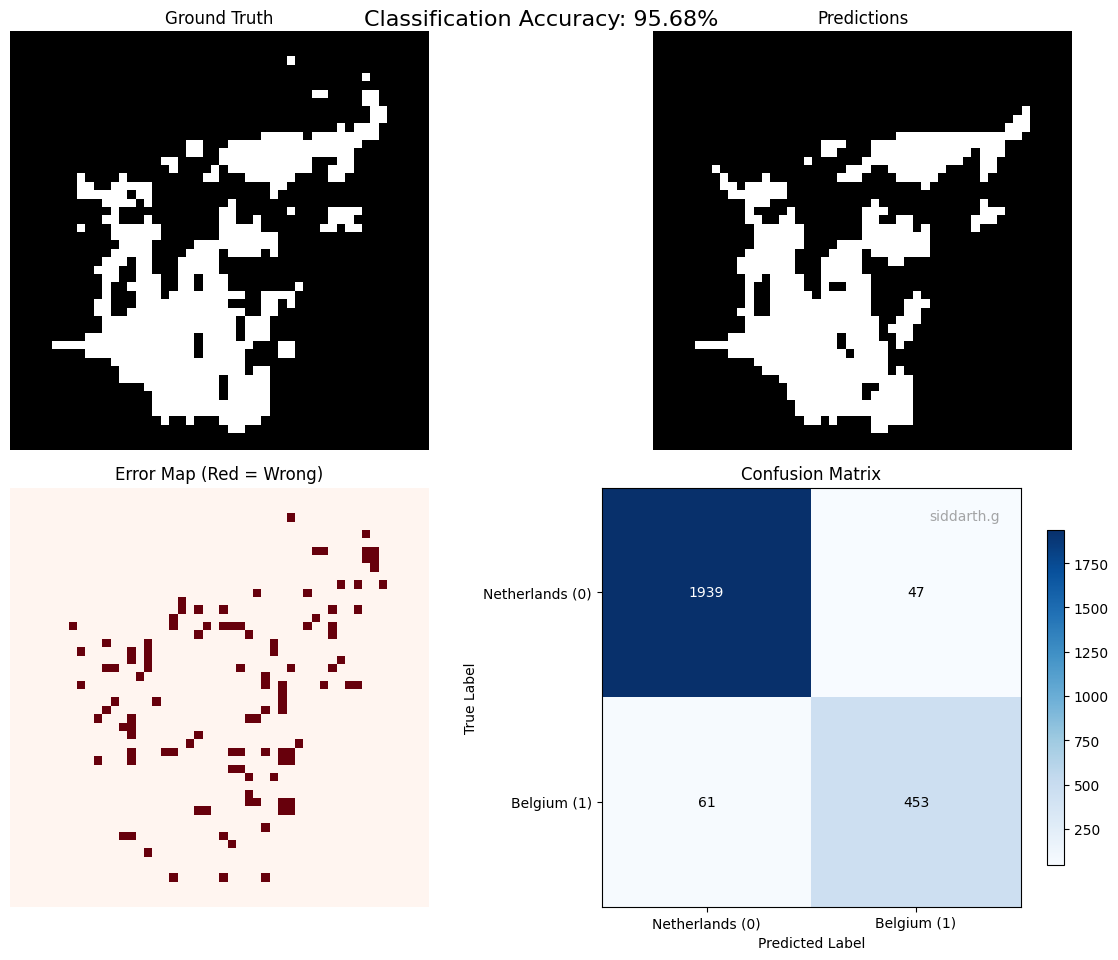

In [77]:
plot_training_history(history)
y_pred = model.predict(X)
y_labels = (y_pred >= 0.5).astype(int)
accuracy = np.mean(y_labels == y)
print(f"Accuracy: {accuracy:.4f}")

# Predict number of 1s and 0s
num_ones = np.sum(y_labels)
num_zeros = y_labels.shape[0] - num_ones
print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")
print(f"Actual number of 1s: {sum(y==1)}, 0s: {sum(y==0)}") # Baseline accuracy is 79.44%

# Print the y_pred values, predictions and true value as 0 or 1
for i in range(5):
    print(f"Input: {X[i*500]}, NN Output: {y_pred[i*500][0]:.4f}, Predicted: {y_labels[i*500][0]}, True: {y[i*500].astype(int)}")

visualization_path = os.path.join(path, f'acc_{accuracy:.3f}.png')
class_visualizer(processor.samples, y_pred, y, accuracy, save_path=visualization_path)

# cm = confusion_matrix(y.astype(int), y_pred.astype(int))
# print(cm)

# Find accuracy on the train set itself
# y_pred = model.predict(X_shuffled)
# y_labels = (y_pred >= 0.5).astype(int)
# accuracy = np.mean(y_labels == y_shuffled)
# num_ones = np.sum(y_labels)
# num_zeros = y_labels.shape[0] - num_ones
# print(f"Train set accuracy: {accuracy:.4f}, Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")

I have tested on several architectures and hyperparameters. It seems like a larger batch size is producing better gradient updates. We can be a little aggressive on the learning rate with a large batch size as well. I have changed the convergence criterion to observe better results as good gradient updates were being produced after several 10s of epochs of small changes.

In [89]:
layer_depths = [2, 3, 4, 5, 6]
layer_widths = [8, 16, 32, 64, 128]

histories = {}
histories['depth'] = {}
histories['width'] = {}
accuracies = {}
accuracies['depth'] = {}
accuracies['width'] = {}

for depth in layer_depths:
    
    print_separator()
    print(f"Training model with depth {depth} and width 64")
    
    layers = []
    # Create layers
    input_size = 2
    for i in range(depth - 1):
        layers.append(Linear(input_size, 64, activation='tanh'))
        input_size = 64
    layers.append(Linear(input_size, 1, activation='sigmoid')) # Output layer
    
    model = Model(layers, loss_type='bce')
    path = 'models/run_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    os.makedirs(path, exist_ok=True)
    
    histories['depth'][depth] = train_model(
        model=model,
        X_train=X,
        y_train=y,
        batch_size=125,
        grad_accumulation_steps=1,
        relative_loss_threshold=0.01,
        learning_rate=0.01,
        num_epochs=10000,
        patience=500,
        save_path=path
    )
    
    # plot_training_history(history)
    y_pred = model.predict(X)
    y_labels = (y_pred >= 0.5).astype(int)
    accuracy = np.mean(y_labels == y)
    accuracies['depth'][depth] = accuracy
    print(f"Accuracy: {accuracy:.4f}")
    
    # Predict number of 1s and 0s
    num_ones = np.sum(y_labels)
    num_zeros = y_labels.shape[0] - num_ones
    print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")
    print(f"Actual number of 1s: {sum(y==1)}, 0s: {sum(y==0)}") # Baseline accuracy is 79.44%

for width in layer_widths:
    
    print_separator()
    print(f"Training model with depth 4 and width {width}")
    
    layers = []
    # Create layers
    input_size = 2
    for i in range(3):
        layers.append(Linear(input_size, width, activation='tanh'))
        input_size = width
    layers.append(Linear(input_size, 1, activation='sigmoid')) # Output layer
    
    model = Model(layers, loss_type='bce')
    path = 'models/run_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
    os.makedirs(path, exist_ok=True)

    histories['width'][width] = train_model(
        model=model,
        X_train=X,
        y_train=y,
        batch_size=250,
        grad_accumulation_steps=1,
        relative_loss_threshold=0.01,
        learning_rate=0.001,
        num_epochs=7500,
        patience=500,
        save_path=path
    )
    
    # plot_training_history(history)
    y_pred = model.predict(X)
    y_labels = (y_pred >= 0.5).astype(int)
    accuracy = np.mean(y_labels == y)
    accuracies['width'][width] = accuracy
    print(f"Accuracy: {accuracy:.4f}")
    
    # Predict number of 1s and 0s
    num_ones = np.sum(y_labels)
    num_zeros = y_labels.shape[0] - num_ones
    print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")
    print(f"Actual number of 1s: {sum(y==1)}, 0s: {sum(y==0)}") # Baseline accuracy is 79.44%



Training model with depth 2 and width 64
Starting training:
Total samples: 2500, Batch size: 125, Batches per epoch: 20
Gradient accumulation steps: 1
Learning rate: 0.01, Max epochs: 10000




Training:  30%|███       | 3005/10000 [00:15<00:35, 195.58epoch/s, loss=564.287045, best=556.367250, no_improve=499]



Early stopping triggered at epoch 3006
Loss improvement less than 1% over last 500 epochs


Training completed! Best loss: 556.367250, total epochs: 3006
Accuracy: 0.9044
Predicted 1s: 471, Predicted 0s: 2029
Actual number of 1s: [514], 0s: [1986]


Training model with depth 3 and width 64
Starting training:
Total samples: 2500, Batch size: 125, Batches per epoch: 20
Gradient accumulation steps: 1
Learning rate: 0.01, Max epochs: 10000




Training: 100%|██████████| 10000/10000 [01:34<00:00, 106.27epoch/s, loss=10.911045, best=9.908928, no_improve=2]    




Training completed! Best loss: 9.908928, total epochs: 10000
Accuracy: 0.9996
Predicted 1s: 515, Predicted 0s: 1985
Actual number of 1s: [514], 0s: [1986]


Training model with depth 4 and width 64
Starting training:
Total samples: 2500, Batch size: 125, Batches per epoch: 20
Gradient accumulation steps: 1
Learning rate: 0.01, Max epochs: 10000




...



Training completed! Best loss: 55.476459, total epochs: 7500
Accuracy: 0.9940
Predicted 1s: 511, Predicted 0s: 1989
Actual number of 1s: [514], 0s: [1986]


Training model with depth 4 and width 64
Starting training:
Total samples: 2500, Batch size: 250, Batches per epoch: 10
Gradient accumulation steps: 1
Learning rate: 0.001, Max epochs: 7500




Training: 100%|██████████| 7500/7500 [01:50<00:00, 68.00epoch/s, loss=15.789167, best=14.779433, no_improve=54]   




Training completed! Best loss: 14.779433, total epochs: 7500
Accuracy: 0.9992
Predicted 1s: 512, Predicted 0s: 1988
Actual number of 1s: [514], 0s: [1986]


Training model with depth 4 and width 128
Starting training:
Total samples: 2500, Batch size: 250, Batches per epoch: 10
Gradient accumulation steps: 1
Learning rate: 0.001, Max epochs: 7500




Training: 100%|██████████| 7500/7500 [05:55<00:00, 21.08epoch/s, loss=8.146316, best=7.901369, no_improve=36]     




Training completed! Best loss: 7.901369, total epochs: 7500
Accuracy: 1.0000
Predicted 1s: 514, Predicted 0s: 1986
Actual number of 1s: [514], 0s: [1986]


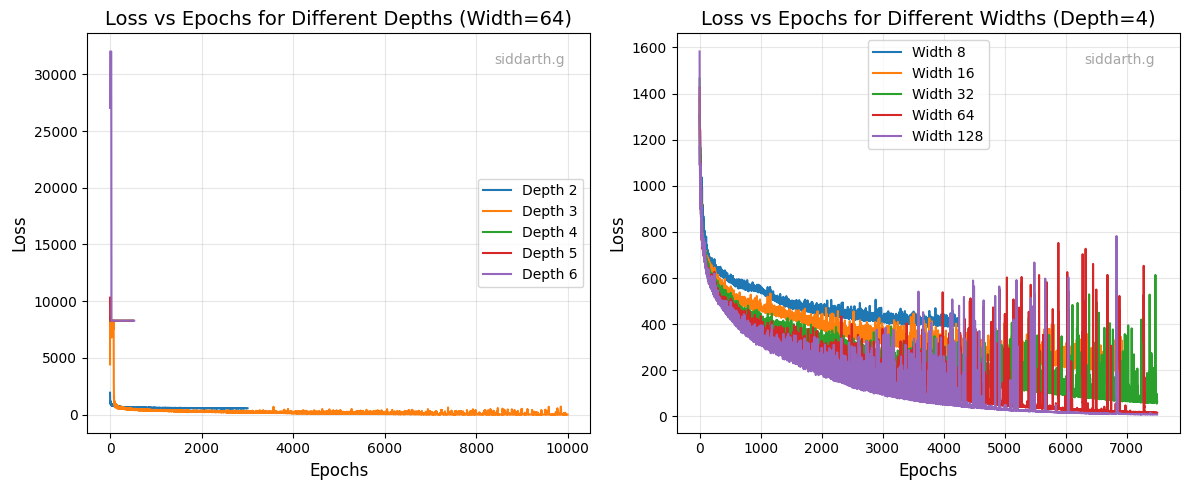

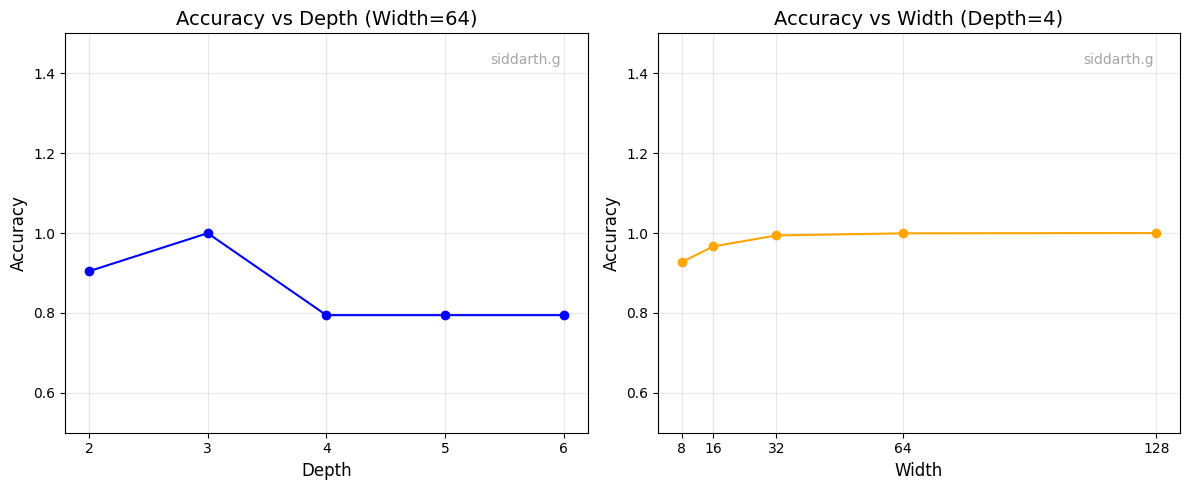

In [91]:
# Plot loss vs epochs for different depths and for different widths
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for depth in layer_depths:
    history = histories['depth'][depth] 
    plt.plot(history['loss_history'], label=f'Depth {depth}')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss vs Epochs for Different Depths (Width=64)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
add_username("siddarth.g")

plt.subplot(1, 2, 2)
for width in layer_widths:
    history = histories['width'][width]
    plt.plot(history['loss_history'], label=f'Width {width}')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Loss vs Epochs for Different Widths (Depth=4)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
add_username("siddarth.g")
plt.tight_layout()
plt.show()

# Plot accuracy plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
depths = list(accuracies['depth'].keys())
depth_acc = [accuracies['depth'][d] for d in depths]
plt.plot(depths, depth_acc, 'o-', label='Depth vs Accuracy', color='blue')
plt.xlabel('Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Depth (Width=64)', fontsize=14)
plt.xticks(depths)
plt.ylim(0.5, 1.5)
plt.grid(True, alpha=0.3)
add_username("siddarth.g")

plt.subplot(1, 2, 2)
widths = list(accuracies['width'].keys())
width_acc = [accuracies['width'][w] for w in widths]
plt.plot(widths, width_acc, 'o-', label='Width vs Accuracy', color='orange')
plt.xlabel('Width', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Width (Depth=4)', fontsize=14)
plt.xticks(widths)
plt.ylim(0.5, 1.5)
plt.grid(True, alpha=0.3)
add_username("siddarth.g")

plt.tight_layout()
plt.show()

Its very tricky to get out of the local minima of the baseline which is why I have increased the patience value. Yet, a few architectures get stuck in this local minima in the range I have tried out. This is particularly true for deep networks with large widths. I figured the gradients vanish as they propagate backwards which leads to the model not improving from baseline. Some techniques that I came across to tackle this issue are residual connections, having larger dataset (not feasible in this case) and tuning the model accordingly!

In this process, I have also stumbled upon an architecture that memorizes the entire dataset! The results are given below.

Starting training:
Total samples: 2500, Batch size: 125, Batches per epoch: 20
Gradient accumulation steps: 1
Learning rate: 0.001, Max epochs: 7500




Training: 100%|██████████| 7500/7500 [01:51<00:00, 67.33epoch/s, loss=79.142867, best=74.419240, no_improve=161]   




Training completed! Best loss: 74.419240, total epochs: 7500


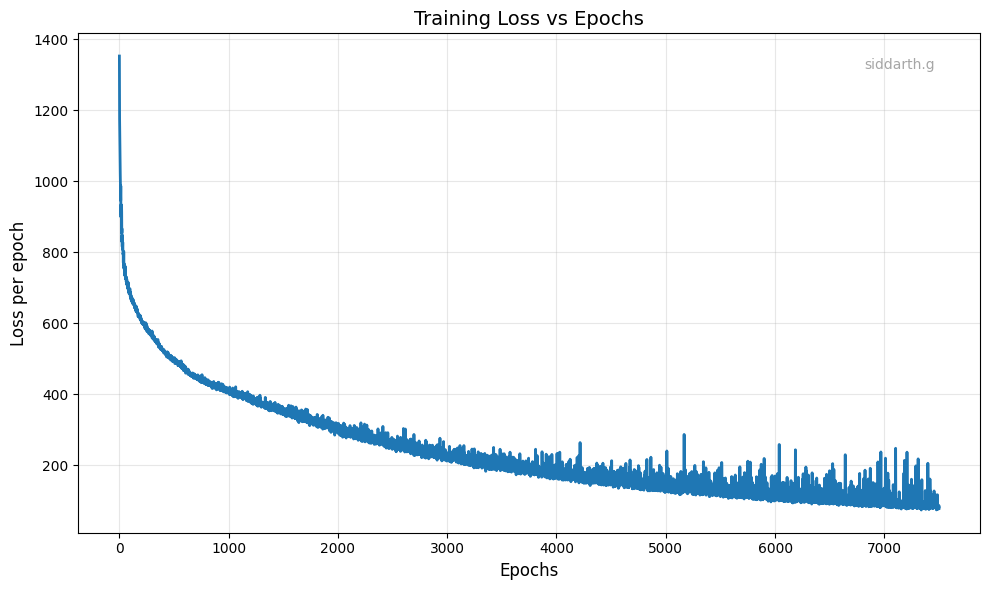

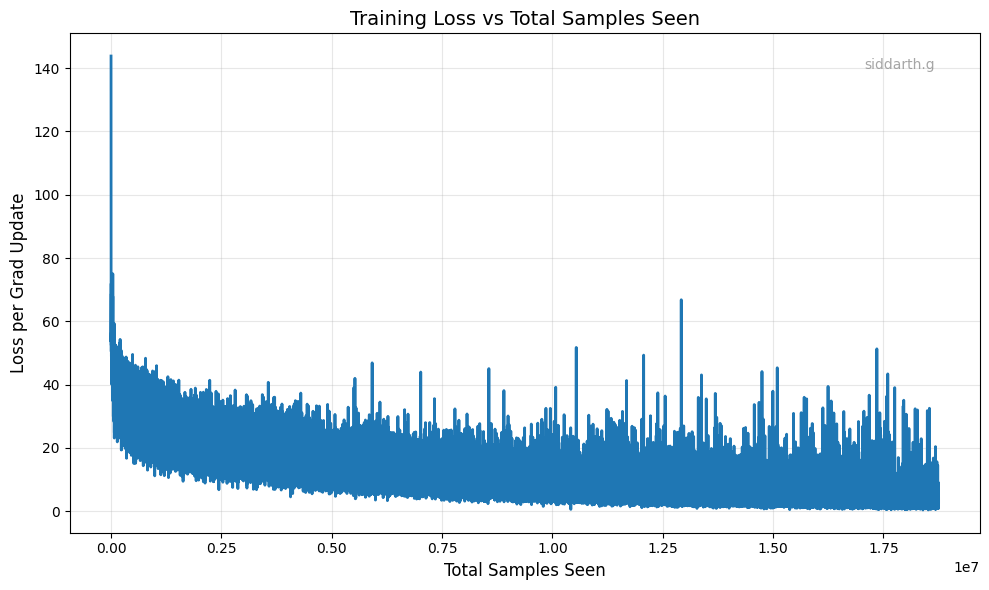

Accuracy: 0.9884
Predicted 1s: 521, Predicted 0s: 1979
Actual number of 1s: [514], 0s: [1986]
Input: [0.34693878 0.28571429], NN Output: 1.0000, Predicted: 1, True: [1]
Input: [0.65306122 0.24489796], NN Output: 0.9972, Predicted: 1, True: [1]
Input: [0.40816327 0.91836735], NN Output: 0.0000, Predicted: 0, True: [0]
Input: [0.         0.26530612], NN Output: 0.0000, Predicted: 0, True: [0]
Input: [0.57142857 0.16326531], NN Output: 0.9999, Predicted: 1, True: [1]


C:\Users\sidda\AppData\Local\Temp\ipykernel_26992\3940925152.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_image[y_pixel, x_pixel] = y_pred_binary[i]
C:\Users\sidda\AppData\Local\Temp\ipykernel_26992\3940925152.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  error_image[y_pixel, x_pixel] = abs(true_label - y_pred_binary[i])


Visualization saved to models/run_2025-10-15_16-32-48\acc_0.988.png


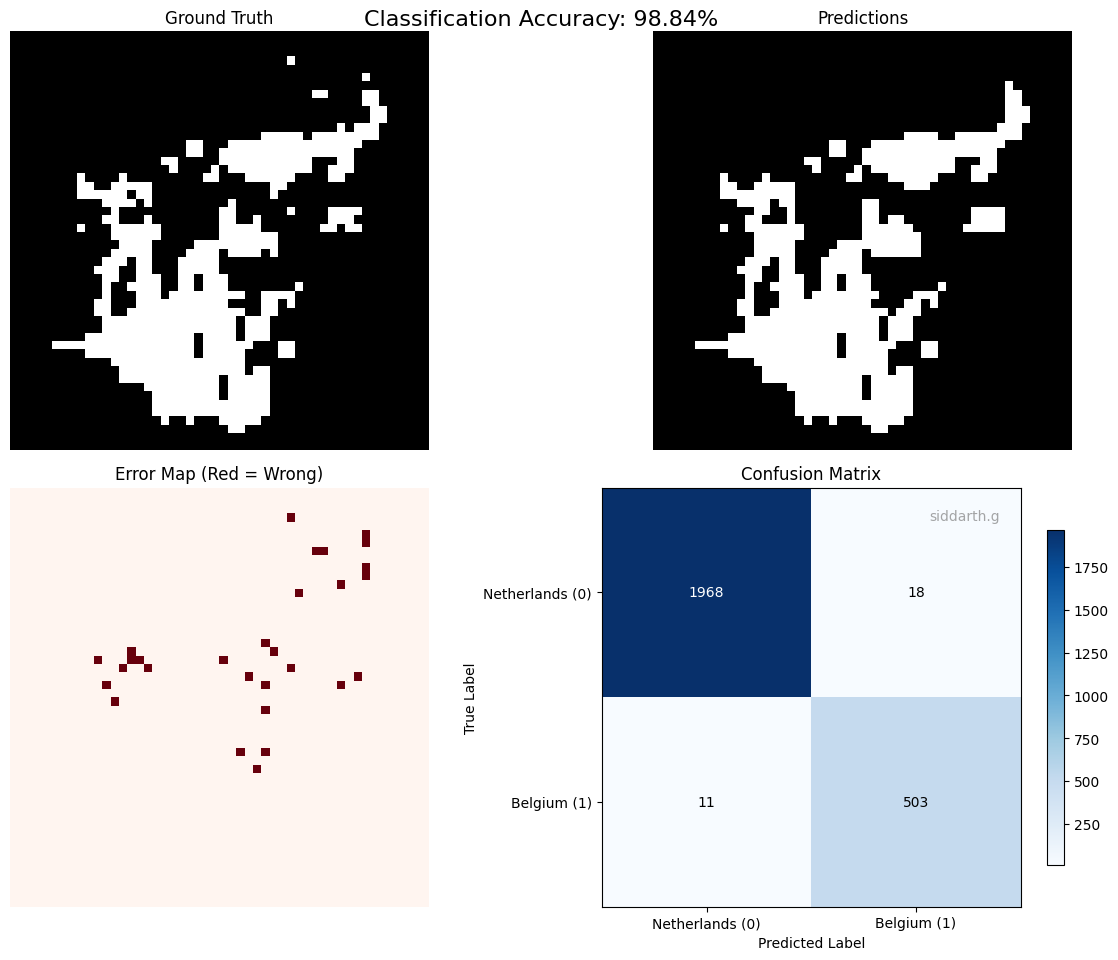

In [94]:
# Model architecture
layers = [
    Linear(2, 32, activation='tanh'),
    Linear(32, 32, activation='tanh'),
    Linear(32, 32, activation='tanh'),
    Linear(32, 1, activation='sigmoid')
]

model = Model(layers, loss_type='bce')
path = 'models/run_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
os.makedirs(path, exist_ok=True)
history = train_model(
    model=model,
    X_train=X,
    y_train=y,
    batch_size=125,
    grad_accumulation_steps=1,
    relative_loss_threshold=0.01,
    learning_rate=0.001,
    num_epochs=7500,
    patience=500,
    save_path=path
)

plot_training_history(history)
y_pred = model.predict(X)
y_labels = (y_pred >= 0.5).astype(int)
accuracy = np.mean(y_labels == y)
print(f"Accuracy: {accuracy:.4f}")

# Predict number of 1s and 0s
num_ones = np.sum(y_labels)
num_zeros = y_labels.shape[0] - num_ones
print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")
print(f"Actual number of 1s: {sum(y==1)}, 0s: {sum(y==0)}") # Baseline accuracy is 79.44%

# Print the y_pred values, predictions and true value as 0 or 1
for i in range(5):
    print(f"Input: {X[i*500]}, NN Output: {y_pred[i*500][0]:.4f}, Predicted: {y_labels[i*500][0]}, True: {y[i*500].astype(int)}")

visualization_path = os.path.join(path, f'acc_{accuracy:.3f}.png')
class_visualizer(processor.samples, y_pred, y, accuracy, save_path=visualization_path)

## Question 1.5 : Final Challenge

Model loaded from models/run_2025-10-15_16-32-48\model_loss_74.419240.npz
Weights pruned


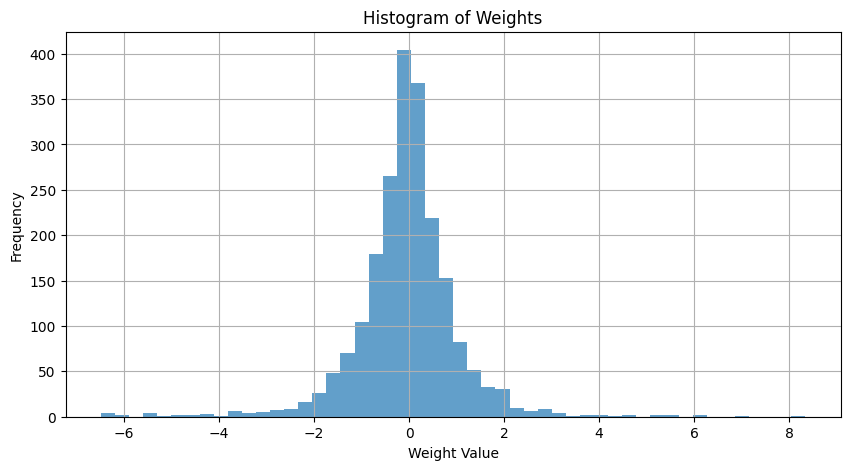

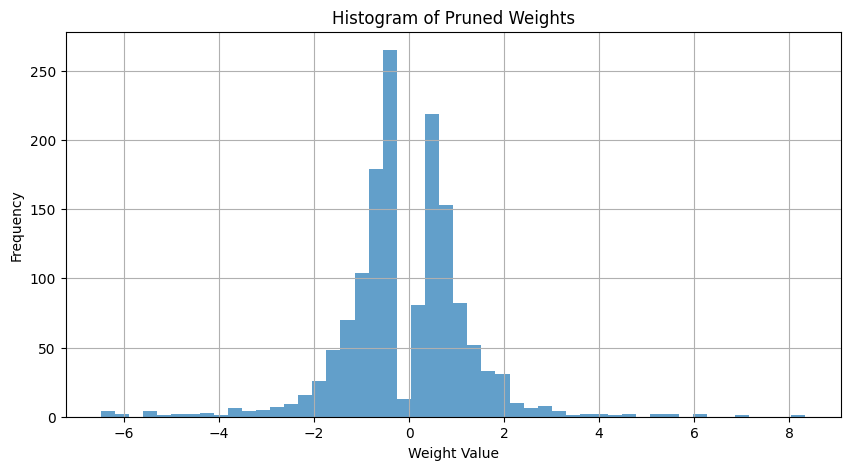

Accuracy after pruning: 0.9492
Predicted 1s: 509, Predicted 0s: 1991
Actual number of 1s: [514], 0s: [1986]
Input: [0.34693878 0.28571429], NN Output: 1.0000, Predicted: 1, True: [1]
Input: [0.65306122 0.24489796], NN Output: 0.9374, Predicted: 1, True: [1]
Input: [0.40816327 0.91836735], NN Output: 0.0000, Predicted: 0, True: [0]
Input: [0.         0.26530612], NN Output: 0.0000, Predicted: 0, True: [0]
Input: [0.57142857 0.16326531], NN Output: 1.0000, Predicted: 1, True: [1]


C:\Users\sidda\AppData\Local\Temp\ipykernel_26992\3940925152.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_image[y_pixel, x_pixel] = y_pred_binary[i]
C:\Users\sidda\AppData\Local\Temp\ipykernel_26992\3940925152.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  error_image[y_pixel, x_pixel] = abs(true_label - y_pred_binary[i])


Visualization saved to models/run_2025-10-15_16-32-48\acc_pruned_0.949.png


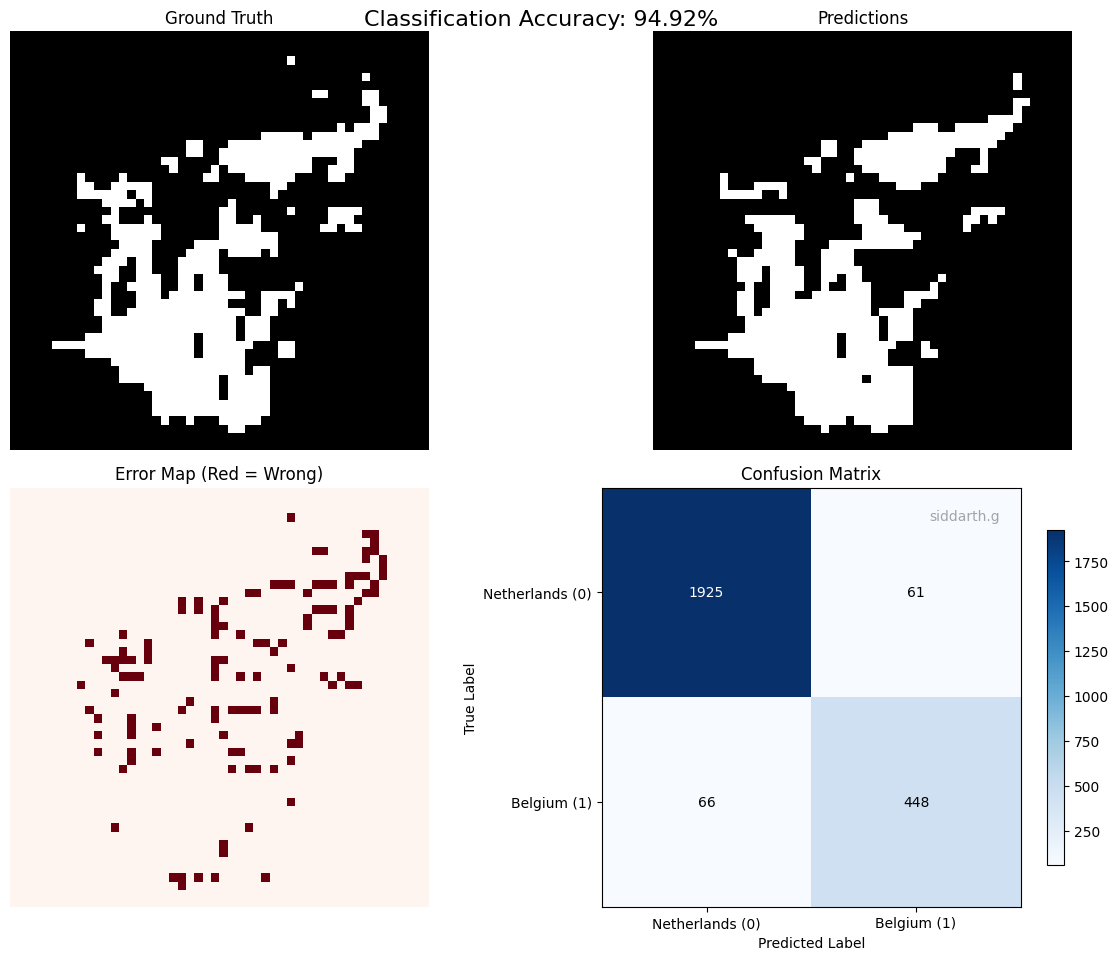

Total weights: 2144, Pruned weights: 678
Percentage of weights pruned: 31.62%
Accuracy before pruning: 0.9884, Accuracy after pruning: 0.9492


In [99]:
random.seed(42)
np.random.seed(42)

def prune_weights(model, path, threshold=0.1):

    all_weights = []
    pruned_weights = []

    # Name ends with .npz, search for it
    model.load_from(os.path.join(path, os.listdir(path)[-1]))

    for layer in model.layers:
        if isinstance(layer, Linear):
            all_weights.extend(layer.weights.flatten())
            layer.weights[np.abs(layer.weights) < threshold] = 0
            layer.biases[np.abs(layer.biases) < threshold] = 0

            # Add non-zero weights to pruned_weights
            pruned_weights.extend(layer.weights[layer.weights != 0].flatten())

    print("Weights pruned")

    # Plot histogram of weights
    plt.figure(figsize=(10, 5))
    plt.hist(np.array(all_weights), bins=50, alpha=0.7)
    plt.title("Histogram of Weights")
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

    # Visualize a histogram of weights after pruning
    plt.figure(figsize=(10, 5))
    plt.hist(np.array(pruned_weights), bins=50, alpha=0.7)
    plt.title("Histogram of Pruned Weights")
    plt.xlabel("Weight Value")
    plt.ylabel("Frequency")
    plt.grid()
    plt.show()

    return all_weights, pruned_weights

all_weights, pruned_weights = prune_weights(model, path, threshold=0.25)
y_pred = model.predict(X)
y_labels = (y_pred >= 0.5).astype(int)
accuracy_pruned = np.mean(y_labels == y)
print(f"Accuracy after pruning: {accuracy_pruned:.4f}")

# Predict number of 1s and 0s
num_ones = np.sum(y_labels)
num_zeros = y_labels.shape[0] - num_ones
print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")
print(f"Actual number of 1s: {sum(y==1)}, 0s: {sum(y==0)}") # Baseline accuracy is 79.44%

# Print the y_pred values, predictions and true value as 0 or 1
for i in range(5):
    print(f"Input: {X[i*500]}, NN Output: {y_pred[i*500][0]:.4f}, Predicted: {y_labels[i*500][0]}, True: {y[i*500].astype(int)}")

visualization_path = os.path.join(path, f'acc_pruned_{accuracy_pruned:.3f}.png')
class_visualizer(processor.samples, y_pred, y, accuracy_pruned, save_path=visualization_path)

# Print pruning stats
total_weights = len(all_weights)
pruned_count = total_weights - len(pruned_weights)
print(f"Total weights: {total_weights}, Pruned weights: {pruned_count}")
print(f"Percentage of weights pruned: {pruned_count / total_weights:.2%}")
print(f"Accuracy before pruning: {accuracy:.4f}, Accuracy after pruning: {accuracy_pruned:.4f}")


Starting training:
Total samples: 2500, Batch size: 125, Batches per epoch: 20
Gradient accumulation steps: 1
Learning rate: 0.001, Max epochs: 1000




Training: 100%|██████████| 1000/1000 [00:24<00:00, 40.08epoch/s, loss=337.814086, best=342.086201, no_improve=24]




Training completed! Best loss: 337.814086, total epochs: 1000


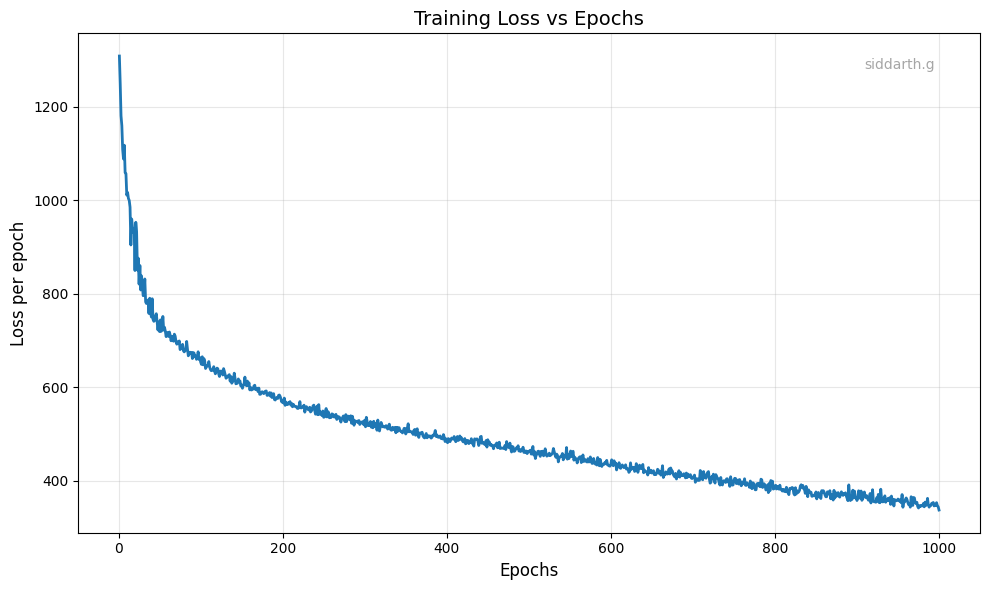

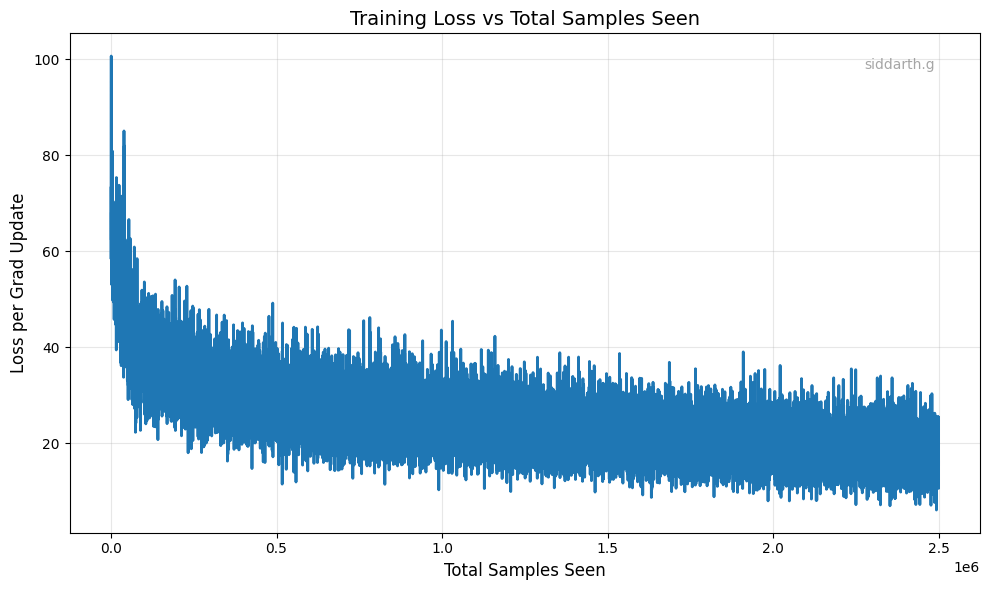

Accuracy: 0.9372
Predicted 1s: 431, Predicted 0s: 2069
Actual number of 1s: [514], 0s: [1986]


C:\Users\sidda\AppData\Local\Temp\ipykernel_26992\3940925152.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_image[y_pixel, x_pixel] = y_pred_binary[i]
C:\Users\sidda\AppData\Local\Temp\ipykernel_26992\3940925152.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  error_image[y_pixel, x_pixel] = abs(true_label - y_pred_binary[i])


Visualization saved to models/run_2025-10-15_17-02-18\acc_0.937.png


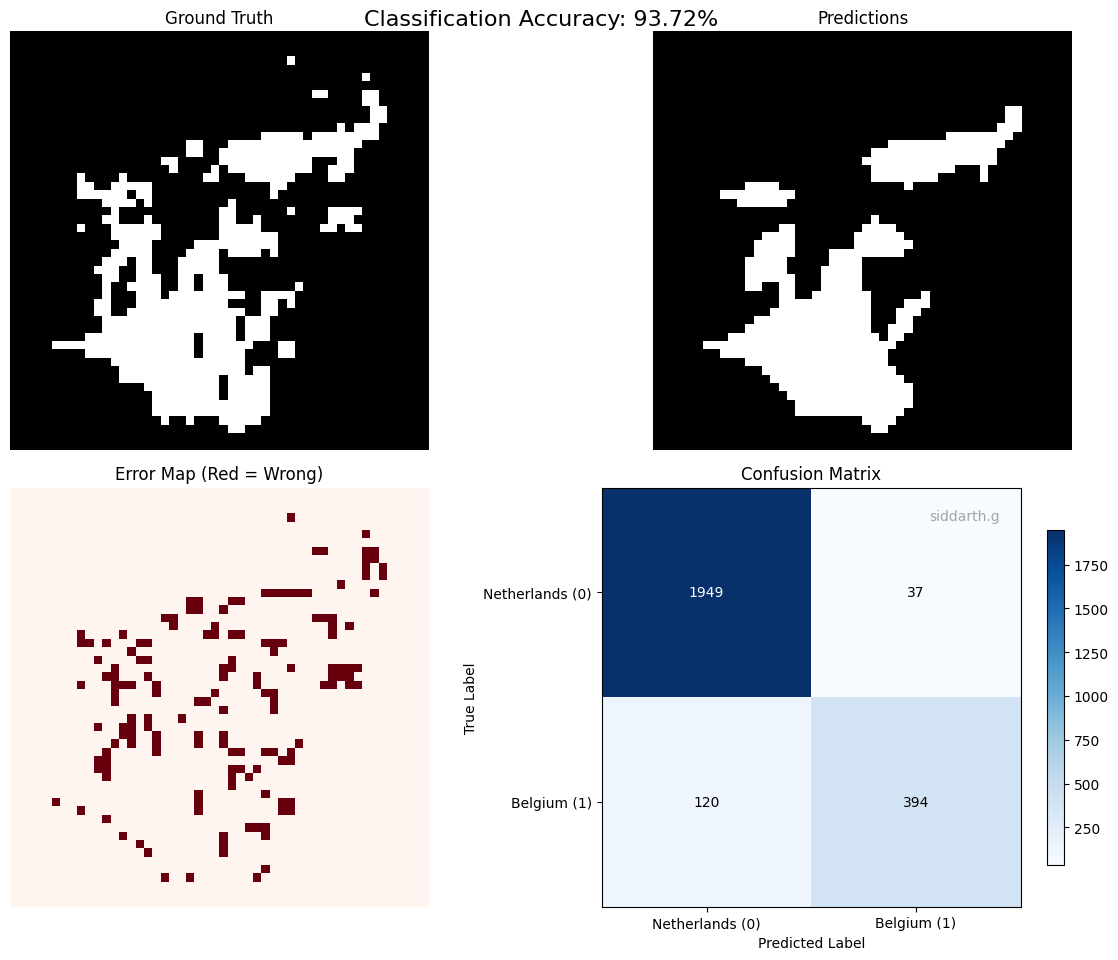

Total samples seen during training: 2.5 million
Previously, total samples seen during training: 18.75 million


In [109]:
random.seed(42)
np.random.seed(42)

# To minimize tranining samples, we will have to reduce the training epochs and be more aggressive on the learning rate. 
# Model architecture
layers = [
    Linear(2, 64, activation='tanh'),
    Linear(64, 64, activation='tanh'),
    Linear(64, 64, activation='tanh'),
    Linear(64, 1, activation='sigmoid')
]

model = Model(layers, loss_type='bce')
path = 'models/run_' + datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
os.makedirs(path, exist_ok=True)
history = train_model(
        model=model,
        X_train=X,
        y_train=y,
        batch_size=125,
        grad_accumulation_steps=1,
        relative_loss_threshold=0.01,
        learning_rate=0.001,
        num_epochs=1000,
        patience=100,
        save_path=path
    )

plot_training_history(history)
y_pred = model.predict(X)
y_labels = (y_pred >= 0.5).astype(int)
accuracy = np.mean(y_labels == y)
print(f"Accuracy: {accuracy:.4f}")

# Predict number of 1s and 0s
num_ones = np.sum(y_labels)
num_zeros = y_labels.shape[0] - num_ones
print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")
print(f"Actual number of 1s: {sum(y==1)}, 0s: {sum(y==0)}") # Baseline accuracy is 79.44%

# Print the y_pred values, predictions and true value as 0 or 1
# for i in range(5):
#     print(f"Input: {X[i*500]}, NN Output: {y_pred[i*500][0]:.4f}, Predicted: {y_labels[i*500][0]}, True: {y[i*500].astype(int)}")

visualization_path = os.path.join(path, f'acc_{accuracy:.3f}.png')
class_visualizer(processor.samples, y_pred, y, accuracy, save_path=visualization_path)
print(f"Total samples seen during training: {history['hyperparameters']['num_epochs'] * len(X) / 1000000} million")
print(f"Previously, total samples seen during training: {7500 * len(X) / 1000000} million")

Model loaded from models/run_2025-10-15_17-02-18\model_loss_337.814086.npz
Weights pruned


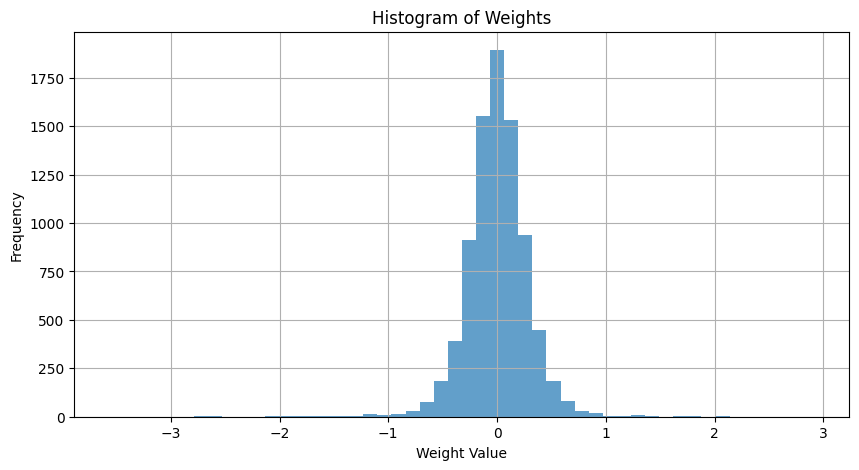

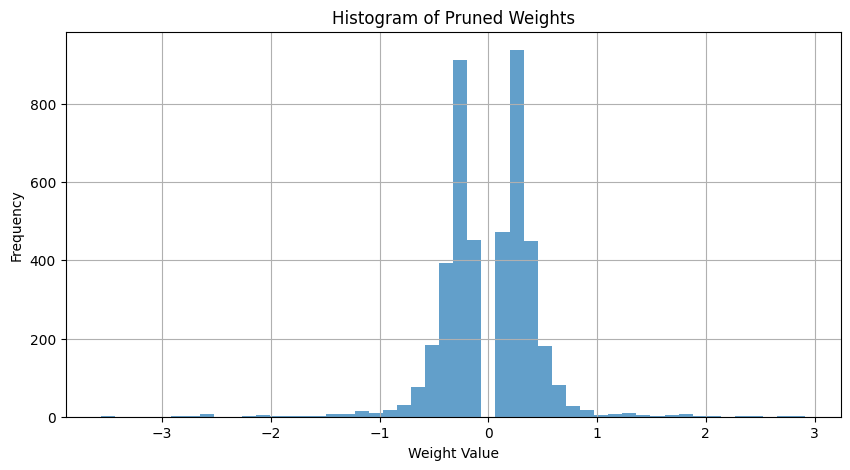

Accuracy after pruning: 0.9176
Predicted 1s: 546, Predicted 0s: 1954
Actual number of 1s: [514], 0s: [1986]


C:\Users\sidda\AppData\Local\Temp\ipykernel_26992\3940925152.py:38: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_image[y_pixel, x_pixel] = y_pred_binary[i]
C:\Users\sidda\AppData\Local\Temp\ipykernel_26992\3940925152.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  error_image[y_pixel, x_pixel] = abs(true_label - y_pred_binary[i])


Visualization saved to models/run_2025-10-15_17-02-18\acc_pruned_0.918.png


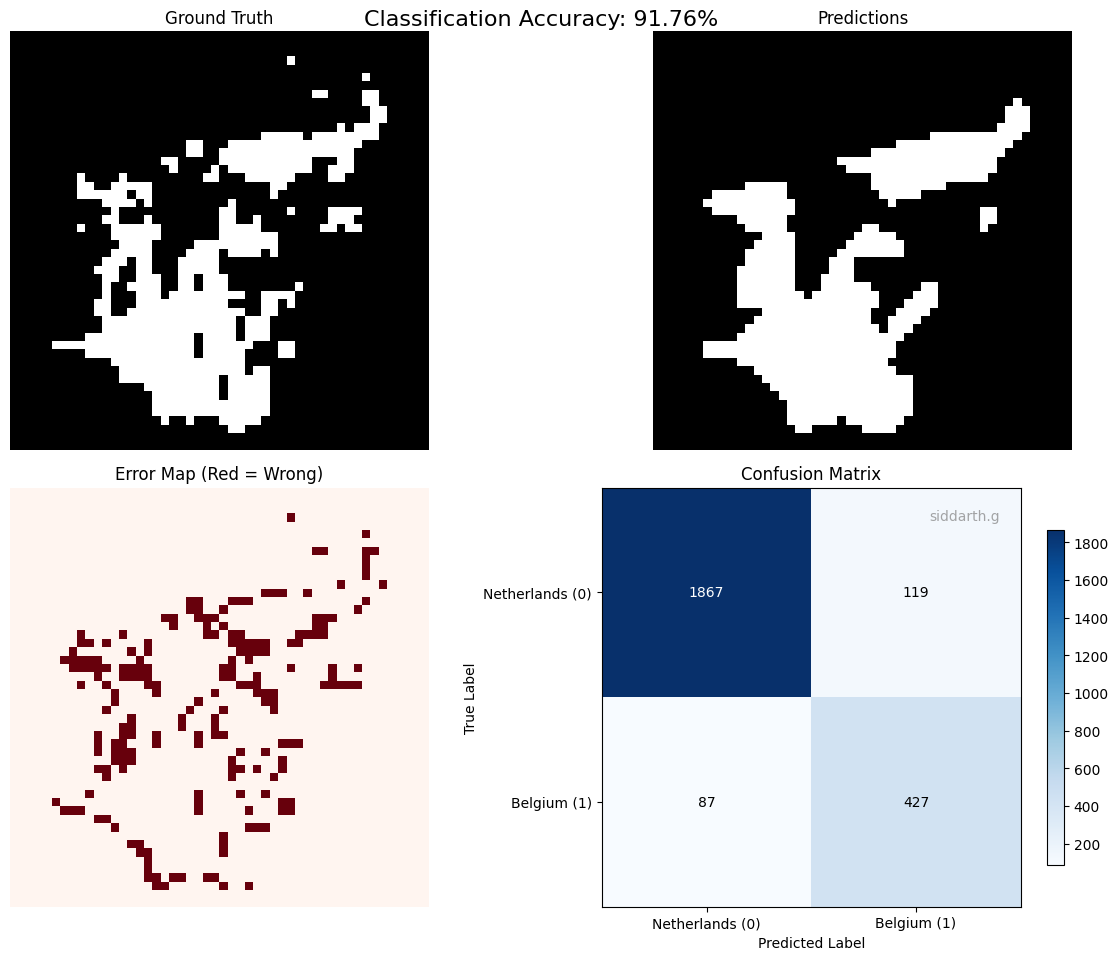

Total weights: 8384, Pruned weights: 4052
Percentage of weights pruned: 48.33%
Accuracy before pruning: 0.9372, Accuracy after pruning: 0.9176


In [111]:
all_weights, pruned_weights = prune_weights(model, path, threshold=0.15)
y_pred = model.predict(X)
y_labels = (y_pred >= 0.5).astype(int)
accuracy_pruned = np.mean(y_labels == y)
print(f"Accuracy after pruning: {accuracy_pruned:.4f}")

# Predict number of 1s and 0s
num_ones = np.sum(y_labels)
num_zeros = y_labels.shape[0] - num_ones
print(f"Predicted 1s: {num_ones}, Predicted 0s: {num_zeros}")
print(f"Actual number of 1s: {sum(y==1)}, 0s: {sum(y==0)}") # Baseline accuracy is 79.44%

# Print the y_pred values, predictions and true value as 0 or 1
# for i in range(5):
#     print(f"Input: {X[i*500]}, NN Output: {y_pred[i*500][0]:.4f}, Predicted: {y_labels[i*500][0]}, True: {y[i*500].astype(int)}")

visualization_path = os.path.join(path, f'acc_pruned_{accuracy_pruned:.3f}.png')
class_visualizer(processor.samples, y_pred, y, accuracy_pruned, save_path=visualization_path)

# Print pruning stats
total_weights = len(all_weights)
pruned_count = total_weights - len(pruned_weights)
print(f"Total weights: {total_weights}, Pruned weights: {pruned_count}")
print(f"Percentage of weights pruned: {pruned_count / total_weights:.2%}")
print(f"Accuracy before pruning: {accuracy:.4f}, Accuracy after pruning: {accuracy_pruned:.4f}")

We see that pruning reduces the weights without much drop in the accuracy and being aggressive in our hyperparameters helps the model learn much faster, again without the accuracy taking a great hit. I also tried to prune the model after trying to minimize the samples it has seen and it has worked out pretty well!

---
### Observations

- To reduce the model size, I have tried to implement pruning. The result observed was that the accuracy dropped by about 4% when nearly 30% of the weights were pruned! This is great as sparse matrices can be stored and multiplied efficiently.
- To reduce the number of training samples seen, I have used a higher learning rate to help the model attain convergence. The batch size is increased to produce much more stable gradient updates. Grad accumulation is done just over 1 step. The patience has been reduced along with the threshold. This is because we don't want the model to spend a lot of epochs without making significant gains. Overall, the number of samples it sees has been brought down from 18.75 million to 2.5 million, about a 7x reduction, with a drop in accuracy of about 4%.
- I have also tried to prune the weights further and found out that about 50% of the weights can be pruned with just a drop in accuracy of 2%!